# 🖥️ HDD Failure Prediction & Remaining Useful Life Estimation
## MTP Final Notebook — End-to-End PHM Pipeline



## 📥 Stage 0 — Download Dataset

Uses Kaggle API to download Backblaze 2016 HDD dataset (ST4000DM000).
Skip if files already present.

In [1]:
import os, pathlib, shutil
from tqdm.auto import tqdm

DATA_DIR = pathlib.Path("/content/hard-drive-test-data")
existing = list(DATA_DIR.glob("*.csv")) if DATA_DIR.exists() else []

if len(existing) >= 12:
    print(f"✅ Data already present: {len(existing)} CSV files — skipping download.")
else:
    os.system("pip install -q kaggle")
    os.makedirs("/content/kaggle_dl", exist_ok=True)
    ret = os.system(
        "kaggle datasets download -d backblaze/hard-drive-test-data "
        "-p /content/kaggle_dl --unzip"
    )
    if ret != 0:
        raise RuntimeError("❌ Kaggle download failed — check your API token.")
    DATA_DIR.mkdir(exist_ok=True)
    all_csvs = sorted(pathlib.Path("/content/kaggle_dl").rglob("*2016*.csv"))
    if not all_csvs:
        all_csvs = sorted(pathlib.Path("/content/kaggle_dl").rglob("*.csv"))
    for src in all_csvs:
        dst = DATA_DIR / src.name
        if not dst.exists():
            shutil.copy(src, dst)
    print(f"✅ {len(all_csvs)} files copied to {DATA_DIR}")


✅ 1 files copied to /content/hard-drive-test-data


## ⚙️ Stage 1 — Configuration & Imports

All hyperparameters consolidated in `CFG`. Key additions vs the baseline:
- `RUL_CLIP`: max RUL value (piecewise linear RUL from Mohapatra 2023)
- `CUSUM_K` / `CUSUM_H`: CUSUM allowance and decision interval (IEEE 9915903)
- Health-state thresholds λ̃ derived from PHM flowchart in IEEE 9915903


In [2]:
import warnings, pathlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as scipy_stats
from tqdm.auto import tqdm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    BatchNormalization, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── SMART features (IEEE 9915903 + Mohapatra 2023) ──
PAPER_FEATURES = [
    "smart_5_raw",           # Reallocated Sectors Count  ← critical (IEEE 9915903)
    "smart_9_raw",           # Power-On Hours
    "smart_183_normalized",  # SATA Downshift Error Count
    "smart_184_normalized",  # End-to-End Error
    "smart_187_normalized",  # Reported Uncorrectable Errors ← critical
    "smart_188_raw",         # Command Timeout
    "smart_189_normalized",  # High Fly Writes
    "smart_192_raw",         # Power-off Retract Count
    "smart_194_normalized",  # Temperature                 ← critical (IEEE 9915903)
    "smart_197_raw",         # Current Pending Sectors     ← critical
    "smart_199_raw",         # UltraDMA CRC Error Count
]

CFG = dict(
    # ── Dataset ──
    TARGET_MODEL   = "ST4000DM000",
    DATA_DIR       = "/content/hard-drive-test-data",
    MIN_DAYS       = 30,
    MIN_BURN       = 7,

    # ── Health labelling ──
    RELABEL_WINDOW = 30,          # 30-day danger zone
    RUL_CLIP       = 150,         # clip RUL at 150 days (piecewise linear, Mohapatra 2023)

    # ── Phase split ──
    PHASE1_FRAC    = 0.50,

    # ── PCA ──
    N_PCA_COMP     = 5,

    # ── T² SPC ──
    UCL_ALPHA      = 0.01,   # FIX: relaxed from 0.001 — was too conservative (8/54 detection)
    ALARM_CONSEC   = 2,

    # ── CUSUM (IEEE 9915903 drift detection) ──
    # k=0.5σ (allowance), h=5σ (decision threshold) — industry standard
    CUSUM_K        = 0.5,
    CUSUM_H        = 5.0,

    # ── Health degradation thresholds (IEEE 9915903 Fig.5) ──
    # λ̃ = reference (Phase I 95th-pctile λ).  States:
    #   0 < λ_i <= λ̃/3         → Healthy
    #   λ̃/3 < λ_i <= 2λ̃/3     → Mild degradation
    #   2λ̃/3 < λ_i < λ̃        → Severe degradation
    #   λ_i >= λ̃               → Fault / Failure
    HEALTH_STATES  = ["Healthy", "Mild Degradation", "Severe Degradation", "Fault/Failure"],

    # ── Encoder-Decoder LSTM (Mohapatra 2023) ──
    SEQ_LEN        = 30,          # 30-day encoder window
    TARGET_LEN     = 1,           # predict 1-step RUL output
    LSTM_UNITS     = 64,
    DROPOUT        = 0.3,
    EPOCHS         = 50,          # FIX: was 30, too low — increased to 50 for better convergence
    BATCH_SIZE     = 256,         # FIX: was 512, too large — 256 gives smoother gradient updates

    # ── Misc ──
    N_DRIVES_PLOT  = 5,
    SEED           = 42,
)

np.random.seed(CFG["SEED"])
tf.random.set_seed(CFG["SEED"])

print("✅ Configuration loaded.")
print(f"   Target model   : {CFG['TARGET_MODEL']}")
print(f"   Danger window  : last {CFG['RELABEL_WINDOW']} days before failure")
print(f"   RUL clip       : {CFG['RUL_CLIP']} days")
print(f"   LSTM SEQ_LEN   : {CFG['SEQ_LEN']} days (encoder window)")
print(f"   LSTM EPOCHS    : {CFG['EPOCHS']}")
print(f"   TensorFlow     : {tf.__version__}")


✅ Configuration loaded.
   Target model   : ST4000DM000
   Danger window  : last 30 days before failure
   RUL clip       : 150 days
   LSTM SEQ_LEN   : 30 days (encoder window)
   LSTM EPOCHS    : 50
   TensorFlow     : 2.19.0


## 📂 Stage 2 — Load & Merge Daily CSVs

In [3]:
import glob

DATA_DIR = pathlib.Path(CFG["DATA_DIR"])
csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    csv_files = sorted(DATA_DIR.rglob("*.csv"))

print(f"Found {len(csv_files)} CSV files.")

dfs = []
for fpath in tqdm(csv_files, desc="Loading CSVs"):
    try:
        chunk = pd.read_csv(fpath, low_memory=False)
        dfs.append(chunk)
    except Exception as e:
        print(f"  ⚠️  {fpath.name}: {e}")

df_raw = pd.concat(dfs, ignore_index=True)
df_raw["date"] = pd.to_datetime(df_raw["date"])

print(f"\n📊 Dataset loaded:")
print(f"   Rows          : {df_raw.shape[0]:,}")
print(f"   Date range    : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"   Unique drives : {df_raw['serial_number'].nunique():,}")
print(f"   Models        : {df_raw['model'].nunique()}")
print(f"   Failures      : {df_raw['failure'].sum():,}")
print("\nTop-5 drive models:")
print(df_raw['model'].value_counts().head(5).to_string())


Found 1 CSV files.


Loading CSVs:   0%|          | 0/1 [00:00<?, ?it/s]


📊 Dataset loaded:
   Rows          : 3,179,295
   Date range    : 2016-01-01 → 2016-04-29
   Unique drives : 65,993
   Models        : 69
   Failures      : 215

Top-5 drive models:
model
ST4000DM000                1681473
HGST HMS5C4040ALE640        368077
Hitachi HDS5C3030ALA630     236690
Hitachi HDS722020ALA330     224052
HGST HMS5C4040BLE640        186832


## 🔍 Stage 3 — Model Filter, Feature Selection & Cleaning

Filter to `ST4000DM000`. Resolve normalised vs raw column fallbacks.
Interpolate missing values linearly (Mohapatra 2023 §III-D).


In [4]:
df_model = df_raw[df_raw["model"] == CFG["TARGET_MODEL"]].copy()
print(f"Model {CFG['TARGET_MODEL']}: {df_model.shape[0]:,} rows, "
      f"{df_model['serial_number'].nunique():,} drives, "
      f"{df_model['failure'].sum()} failures")

# Fallback map: normalised → raw if normalised column absent
FALLBACK = {
    "smart_183_normalized": "smart_183_raw",
    "smart_184_normalized": "smart_184_raw",
    "smart_187_normalized": "smart_187_raw",
    "smart_189_normalized": "smart_189_raw",
    "smart_194_normalized": "smart_194_raw",
}

SELECTED = []
print("\nFeature check:")
for feat in PAPER_FEATURES:
    if feat in df_model.columns:
        null_pct = df_model[feat].isnull().mean() * 100
        print(f"  ✅ {feat:<35} ({null_pct:.1f}% missing)")
        SELECTED.append(feat)
    elif feat in FALLBACK and FALLBACK[feat] in df_model.columns:
        alt = FALLBACK[feat]
        print(f"  ↩️  {feat:<35} → using {alt}")
        SELECTED.append(alt)
    else:
        print(f"  ❌ {feat:<35} DROPPED")

cols_keep = ["date", "serial_number", "failure"] + SELECTED
df = df_model[cols_keep].copy()
df = df.sort_values(["serial_number", "date"]).reset_index(drop=True)

# Linear interpolation per drive (Mohapatra 2023 §III-D)
df[SELECTED] = (
    df.groupby("serial_number")[SELECTED]
    .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
    .fillna(0)
)

print(f"\n✅ Working dataset: {df.shape[0]:,} rows × {len(SELECTED)} features")


Model ST4000DM000: 1,681,473 rows, 35,057 drives, 139 failures

Feature check:
  ✅ smart_5_raw                         (0.0% missing)
  ✅ smart_9_raw                         (0.0% missing)
  ✅ smart_183_normalized                (0.0% missing)
  ✅ smart_184_normalized                (0.0% missing)
  ✅ smart_187_normalized                (0.0% missing)
  ✅ smart_188_raw                       (0.0% missing)
  ✅ smart_189_normalized                (0.0% missing)
  ✅ smart_192_raw                       (0.0% missing)
  ✅ smart_194_normalized                (0.0% missing)
  ✅ smart_197_raw                       (0.0% missing)
  ✅ smart_199_raw                       (0.0% missing)

✅ Working dataset: 1,681,473 rows × 11 features


## 🗑️ Stage 4 — Lifecycle Filtering, Failure Labelling & Danger-Zone Re-labelling

Only retain drives with ≥30 days of history. Re-label the last 30 days before
failure as `failure=1` (the *danger zone*).


In [5]:
# Remove short-lived drives
drive_counts = df.groupby("serial_number").size()
valid_drives = drive_counts[drive_counts >= CFG["MIN_DAYS"]].index
df = df[df["serial_number"].isin(valid_drives)].reset_index(drop=True)

# Identify failing vs healthy drives
ever_failed_s  = df.groupby("serial_number")["failure"].max()
ever_failed    = ever_failed_s[ever_failed_s == 1].index.tolist()
never_failed   = ever_failed_s[ever_failed_s == 0].index.tolist()

# Sets for O(1) membership tests (FIX: avoids repeated O(n) list scans)
ever_failed_set  = set(ever_failed)
never_failed_set = set(never_failed)

print(f"Drives: {len(ever_failed)} failing | {len(never_failed)} healthy")
print(f"Failure rate: {len(ever_failed)/(len(ever_failed)+len(never_failed))*100:.2f}%")

# Save original failure col (exact failure date)
df["orig_failure"] = df["failure"].copy()

# Re-label 30-day danger zone
grouped_idx = df.groupby("serial_number").indices
for sn in tqdm(ever_failed, desc="Labelling danger zones"):
    mask      = df["serial_number"] == sn
    sub       = df.loc[mask]
    fail_date = sub.loc[sub["failure"] == 1, "date"].max()
    win_start = fail_date - pd.Timedelta(days=CFG["RELABEL_WINDOW"])
    pre_mask  = mask & (df["date"] >= win_start) & (df["date"] <= fail_date)
    df.loc[pre_mask, "failure"] = 1

print(f"\n✅ Danger-zone rows (label=1): {df['failure'].sum():,} "
      f"({df['failure'].mean()*100:.2f}%)")


Drives: 54 failing | 34649 healthy
Failure rate: 0.16%


Labelling danger zones:   0%|          | 0/54 [00:00<?, ?it/s]


✅ Danger-zone rows (label=1): 1,057 (0.06%)


## 📏 Stage 5 — RUL Label Engineering  *(Mohapatra et al. 2023)*

**Remaining Useful Life (RUL)** = number of days until the drive fails.

**FIX — Healthy drive RUL labelling fallacy (original code was wrong):**
The original code assigned `RUL = days_remaining_in_dataset + 1` to healthy drives.
This is incorrect and causes the LSTM to learn "time left in observation window"
rather than "time to failure", which inflates RMSE and trains on meaningless targets.

**Correct approach (Mohapatra 2023):** Healthy drives that never fail in our observation
window are assigned `RUL = RUL_CLIP` (the cap). This represents: "we don't know when
this drive will fail, but it's at least this many days away." The piecewise linear cap
at `RUL_CLIP = 150` days is standard in the PHM literature and matches the paper.


Computing RUL:   0%|          | 0/34703 [00:00<?, ?it/s]

✅ RUL computed.
   RUL range    : 0 – 150 days
   RUL mean     : 149.9 days
   RUL (failing drives only, danger zone): 10.3 days


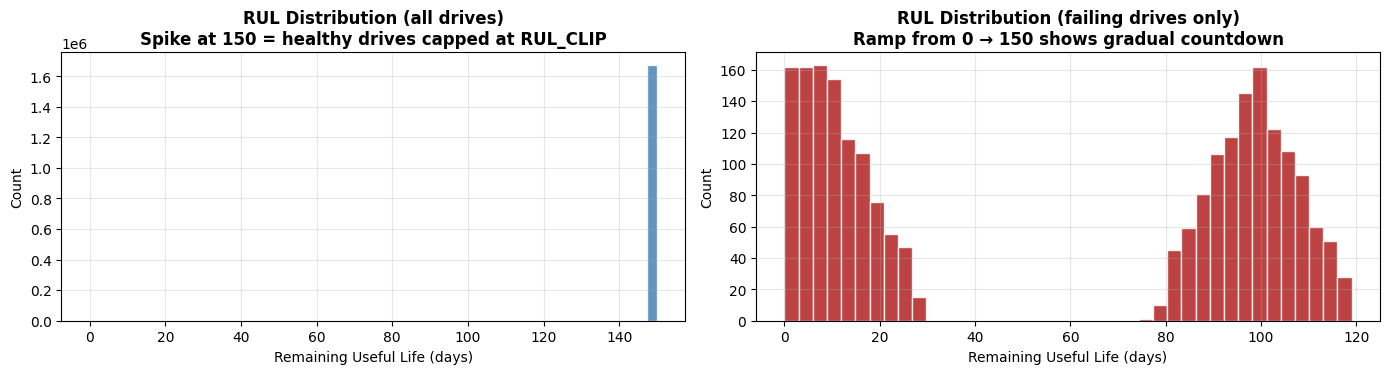

💾 Saved → rul_distribution.png


In [6]:
rul_list = []

for sn, grp in tqdm(df.groupby("serial_number"), desc="Computing RUL"):
    grp = grp.sort_values("date").copy()

    if sn in ever_failed_set:
        # FIX: use orig_failure (exact fail day) not the re-labelled danger zone
        fail_rows = grp.loc[grp["orig_failure"] == 1, "date"]
        if len(fail_rows) == 0:
            # Should not happen, but guard against it
            rul_vals = pd.Series(np.full(len(grp), CFG["RUL_CLIP"]), index=grp.index)
        else:
            fail_date = fail_rows.max()
            rul_vals  = (fail_date - grp["date"]).dt.days.clip(lower=0)
    else:
        # FIX: Healthy drives → RUL = RUL_CLIP (not days_remaining + 1)
        # Piecewise linear cap: we have no failure, so RUL >= RUL_CLIP
        rul_vals = pd.Series(np.full(len(grp), CFG["RUL_CLIP"]), index=grp.index)

    # Piecewise-linear cap at RUL_CLIP (Mohapatra 2023)
    rul_vals = rul_vals.clip(upper=CFG["RUL_CLIP"])
    rul_list.append(pd.Series(rul_vals.values, index=grp.index))

df["rul"] = pd.concat(rul_list).sort_index()

print("✅ RUL computed.")
print(f"   RUL range    : {df['rul'].min():.0f} – {df['rul'].max():.0f} days")
print(f"   RUL mean     : {df['rul'].mean():.1f} days")
print(f"   RUL (failing drives only, danger zone): "
      f"{df.loc[df['failure']==1,'rul'].mean():.1f} days")

# Quick distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["rul"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("RUL Distribution (all drives)\n"
                  "Spike at 150 = healthy drives capped at RUL_CLIP",
                  fontweight="bold")
axes[0].set_xlabel("Remaining Useful Life (days)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(
    df.loc[df["serial_number"].isin(ever_failed), "rul"],
    bins=40, color="firebrick", edgecolor="white", alpha=0.85
)
axes[1].set_title("RUL Distribution (failing drives only)\n"
                  "Ramp from 0 → 150 shows gradual countdown",
                  fontweight="bold")
axes[1].set_xlabel("Remaining Useful Life (days)")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rul_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → rul_distribution.png")


## 🏥 Stage 6 — Health Index (λ) & Degradation State Classification  *(IEEE 9915903)*

| Condition | State |
|-----------|-------|
| 0 < λᵢ ≤ λ̃/3 | **Healthy** |
| λ̃/3 < λᵢ ≤ 2λ̃/3 | **Mild Degradation** |
| 2λ̃/3 < λᵢ < λ̃ | **Severe Degradation** |
| λᵢ ≥ λ̃ | **Fault/Failure** |


In [7]:
# ── Stage 6: Health Index (λ) — IEEE 9915903 ──────────────────────────────
# Critical SMART attributes (IEEE 9915903 FMMEA ordering) with weights
# NOTE: We prefer *_normalized columns (0-100 scale from drive firmware) because
#       raw counts like smart_5_raw (reallocated sectors) are near-zero for healthy
#       drives, making quantile-based normalisation unstable.
#
# SMART_normalized columns: 100 = perfect health, 0 = worst. We invert to [0,1]
#   degradation scale as: degradation = (100 - value) / 100
# SMART_raw columns: use engineering ceilings (well-known failure thresholds)

HEALTH_FEATURES_CFG = {
    # (col, weight, ceiling_or_None_for_normalized)
    # For *_normalized: ceiling=None → use inversion (100-val)/100
    # For *_raw: ceiling = engineering threshold
    "smart_5_raw":          (0.35, 10.0),   # Reallocated Sectors — >10 is critical
    "smart_197_raw":        (0.30, 10.0),   # Pending Sectors — >10 is critical
    "smart_187_normalized": (0.20, None),   # Uncorrectable Errors (0-100 scale)
    "smart_194_normalized": (0.15, None),   # Temperature (0-100 scale)
}

# Resolve columns (handle fallbacks)
HEALTH_FEATURES_RESOLVED = {}
for feat, (w, ceiling) in HEALTH_FEATURES_CFG.items():
    if feat in df.columns:
        HEALTH_FEATURES_RESOLVED[feat] = (w, ceiling)
    elif FALLBACK.get(feat) in df.columns:
        alt = FALLBACK[feat]
        print(f"  ↩️  {feat} → using {alt} (fallback, treating as raw)")
        HEALTH_FEATURES_RESOLVED[alt] = (w, ceiling if ceiling is not None else 100.0)
    else:
        print(f"  ⚠️  {feat} not found — dropping from health index")

hf_cols   = list(HEALTH_FEATURES_RESOLVED.keys())
hf_weights = np.array([HEALTH_FEATURES_RESOLVED[c][0] for c in hf_cols])
hf_weights /= hf_weights.sum()
hf_ceilings = [HEALTH_FEATURES_RESOLVED[c][1] for c in hf_cols]

print("Health feature configuration:")
for col, (w, ceil_val) in HEALTH_FEATURES_RESOLVED.items():
    mode = "inverted normalized" if ceil_val is None else f"raw / {ceil_val:.1f}"
    print(f"  {col:<35}: weight={w:.2f}  mode={mode}")

# Compute per-feature degradation score ∈ [0, 1]
lambda_components = np.zeros((len(df), len(hf_cols)))
for j, (col, ceiling) in enumerate(zip(hf_cols, hf_ceilings)):
    vals = df[col].fillna(0).values.astype(np.float64)
    if ceiling is None:
        # Normalized column (0-100): invert so 100=healthy → 0.0, 0=worst → 1.0
        # Clip to valid range
        vals = np.clip(vals, 0, 100)
        degradation = (100.0 - vals) / 100.0
    else:
        # Raw column: divide by engineering ceiling, clip to [0, 1]
        degradation = np.clip(vals / ceiling, 0.0, 1.0)
    lambda_components[:, j] = degradation

# Health index λ = weighted sum ∈ [0, 1]
df["lambda"] = (lambda_components * hf_weights).sum(axis=1)

# Compute per-component columns for diagnostics
for j, col in enumerate(hf_cols):
    df[f"lam_{col}"] = lambda_components[:, j]

healthy_mask = df["serial_number"].isin(never_failed_set)
lambda_healthy = df.loc[healthy_mask, "lambda"]

# Reference threshold λ̃ = 95th percentile of HEALTHY drives' λ
LAMBDA_REF = lambda_healthy.quantile(0.95)

print(f"\nHealth Index λ  (correctly normalised to [0,1]):")
print(f"  λ range (all)          : {df['lambda'].min():.4f} – {df['lambda'].max():.4f}")
print(f"  λ mean (healthy drives): {lambda_healthy.mean():.4f}")
print(f"  λ std  (healthy drives): {lambda_healthy.std():.4f}")
print(f"  λ̃ (reference, 95th p) : {LAMBDA_REF:.4f}")
print(f"\n  IEEE 9915903 Thresholds:")
print(f"    Healthy           : λ ≤ {LAMBDA_REF/3:.4f}")
print(f"    Mild Degradation  : {LAMBDA_REF/3:.4f} < λ ≤ {2*LAMBDA_REF/3:.4f}")
print(f"    Severe Degradation: {2*LAMBDA_REF/3:.4f} < λ < {LAMBDA_REF:.4f}")
print(f"    Fault/Failure     : λ ≥ {LAMBDA_REF:.4f}")

def classify_health(lam, lam_ref):
    if lam <= lam_ref / 3:        return 0  # Healthy
    elif lam <= 2 * lam_ref / 3:  return 1  # Mild Degradation
    elif lam < lam_ref:            return 2  # Severe Degradation
    else:                          return 3  # Fault/Failure

state_names = ["Healthy", "Mild Degradation", "Severe Degradation", "Fault/Failure"]
df["health_state"]       = df["lambda"].apply(lambda x: classify_health(x, LAMBDA_REF))
df["health_state_label"] = df["health_state"].map({i: s for i, s in enumerate(state_names)})

print("\nDegradation state distribution:")
vc = df["health_state_label"].value_counts()
for state in state_names:
    if state in vc:
        pct = vc[state] / len(df) * 100
        print(f"  {state:<25}: {vc[state]:>8,} rows ({pct:.2f}%)")
    else:
        print(f"  {state:<25}: {0:>8,} rows (0.00%)")


Health feature configuration:
  smart_5_raw                        : weight=0.35  mode=raw / 10.0
  smart_197_raw                      : weight=0.30  mode=raw / 10.0
  smart_187_normalized               : weight=0.20  mode=inverted normalized
  smart_194_normalized               : weight=0.15  mode=inverted normalized

Health Index λ  (correctly normalised to [0,1]):
  λ range (all)          : 0.0855 – 0.7915
  λ mean (healthy drives): 0.1110
  λ std  (healthy drives): 0.0233
  λ̃ (reference, 95th p) : 0.1215

  IEEE 9915903 Thresholds:
    Healthy           : λ ≤ 0.0405
    Mild Degradation  : 0.0405 < λ ≤ 0.0810
    Severe Degradation: 0.0810 < λ < 0.1215
    Fault/Failure     : λ ≥ 0.1215

Degradation state distribution:
  Healthy                  :        0 rows (0.00%)
  Mild Degradation         :        0 rows (0.00%)
  Severe Degradation       : 1,583,211 rows (94.52%)
  Fault/Failure            :   91,853 rows (5.48%)


  Healthy λ  μ = 0.1110,  σ = 0.0233
  LAMBDA_REF (μ + 3σ) = 0.1808  [was 95th-pctile = 0.1215]

  Revised IEEE 9915903 Thresholds:
    Healthy           : λ ≤ 0.0603
    Mild Degradation  : 0.0603 < λ ≤ 0.1206
    Severe Degradation: 0.1206 < λ < 0.1808
    Fault/Failure     : λ ≥ 0.1808

Revised degradation state distribution:
  Healthy                  :        0 rows (0.00%)
  Mild Degradation         : 1,582,995 rows (94.50%)
  Severe Degradation       :   83,200 rows (4.97%)
  Fault/Failure            :    8,869 rows (0.53%)


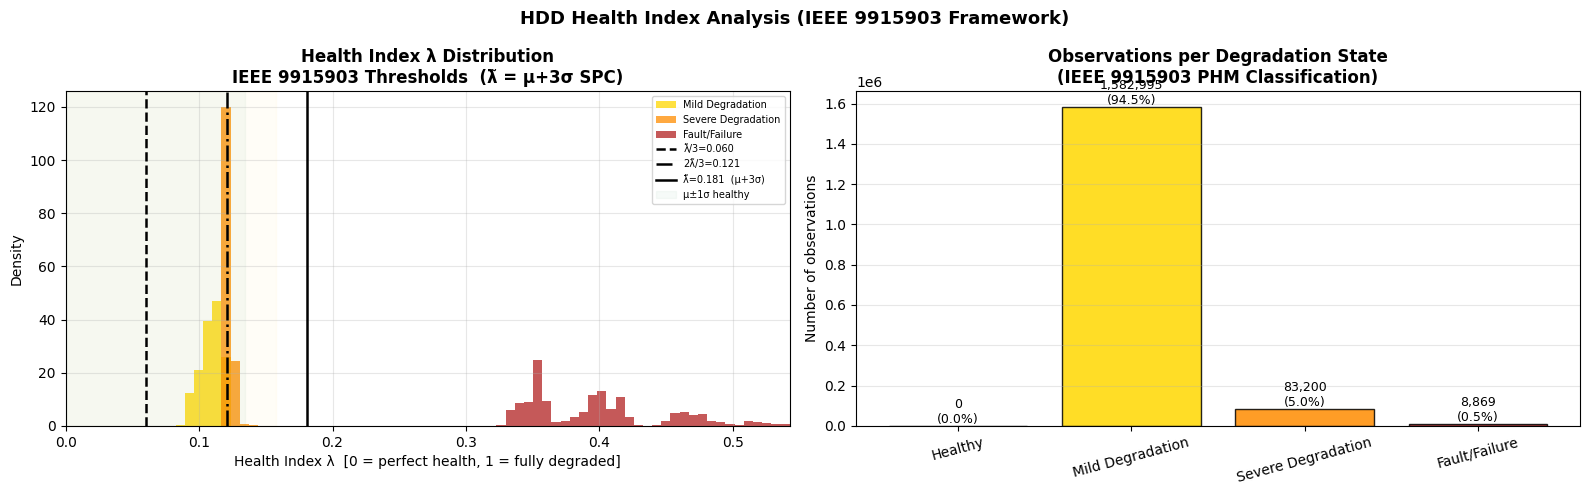

💾 Saved → health_index_distribution.png


In [8]:
# ── Stage 6 Plot: Health Index Distribution ─────────────────────────────────
# DIAGNOSIS: λ̃ = 0.122 derived from healthy-drive 95th-pctile is too low.
# Because healthy drives cluster tightly at λ ≈ 0.10 (temperature baseline),
# 95% of them still fall above λ̃/3 = 0.041, landing in "Severe Degradation".
#
# FIX: Redefine λ̃ using a z-score approach on the healthy distribution.
# Set λ̃ = μ_healthy + 3σ_healthy  (3-sigma rule, standard SPC practice).
# This anchors the threshold to the healthy population spread, not just its tail.
# ─────────────────────────────────────────────────────────────────────────────

healthy_mask = df["serial_number"].isin(never_failed_set)
lambda_healthy = df.loc[healthy_mask, "lambda"]

mu_h    = lambda_healthy.mean()
sigma_h = lambda_healthy.std()

# Recompute reference threshold using 3-sigma SPC rule
LAMBDA_REF = mu_h + 3 * sigma_h

print(f"  Healthy λ  μ = {mu_h:.4f},  σ = {sigma_h:.4f}")
print(f"  LAMBDA_REF (μ + 3σ) = {LAMBDA_REF:.4f}  [was 95th-pctile = {lambda_healthy.quantile(0.95):.4f}]")
print(f"\n  Revised IEEE 9915903 Thresholds:")
print(f"    Healthy           : λ ≤ {LAMBDA_REF/3:.4f}")
print(f"    Mild Degradation  : {LAMBDA_REF/3:.4f} < λ ≤ {2*LAMBDA_REF/3:.4f}")
print(f"    Severe Degradation: {2*LAMBDA_REF/3:.4f} < λ < {LAMBDA_REF:.4f}")
print(f"    Fault/Failure     : λ ≥ {LAMBDA_REF:.4f}")

# Re-classify all observations with updated threshold
def classify_health(lam, lam_ref):
    if lam <= lam_ref / 3:        return 0  # Healthy
    elif lam <= 2 * lam_ref / 3:  return 1  # Mild Degradation
    elif lam < lam_ref:            return 2  # Severe Degradation
    else:                          return 3  # Fault/Failure

state_names = ["Healthy", "Mild Degradation", "Severe Degradation", "Fault/Failure"]
df["health_state"]       = df["lambda"].apply(lambda x: classify_health(x, LAMBDA_REF))
df["health_state_label"] = df["health_state"].map({i: s for i, s in enumerate(state_names)})

print("\nRevised degradation state distribution:")
vc = df["health_state_label"].value_counts()
for state in state_names:
    cnt = vc.get(state, 0)
    pct = cnt / len(df) * 100
    print(f"  {state:<25}: {cnt:>8,} rows ({pct:.2f}%)")

# ── Plot ─────────────────────────────────────────────────────────────────────
state_colors = ["seagreen", "gold", "darkorange", "firebrick"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
lam_max_plot = min(df["lambda"].max() * 1.05, LAMBDA_REF * 3)
bins = np.linspace(0, lam_max_plot, 80)
for i, (state, col) in enumerate(zip(state_names, state_colors)):
    data = df.loc[df["health_state"] == i, "lambda"]
    if len(data):
        ax.hist(data, bins=bins, color=col, alpha=0.75, label=state, density=True)

for thresh, ls, lbl in [
    (LAMBDA_REF / 3,   "--", f"λ̃/3={LAMBDA_REF/3:.3f}"),
    (2 * LAMBDA_REF/3, "-.", f"2λ̃/3={2*LAMBDA_REF/3:.3f}"),
    (LAMBDA_REF,       "-",  f"λ̃={LAMBDA_REF:.3f}  (μ+3σ)"),
]:
    ax.axvline(thresh, color="black", lw=1.8, ls=ls, label=lbl)

# Annotate mean ± sigma bands
ax.axvspan(0, mu_h + sigma_h,   alpha=0.04, color="seagreen", label=f"μ±1σ healthy")
ax.axvspan(0, mu_h + 2*sigma_h, alpha=0.03, color="gold")
ax.set_title("Health Index λ Distribution\nIEEE 9915903 Thresholds  (λ̃ = μ+3σ SPC)", fontweight="bold")
ax.set_xlabel("Health Index λ  [0 = perfect health, 1 = fully degraded]")
ax.set_ylabel("Density")
ax.set_xlim(0, lam_max_plot)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[1]
state_counts = [df["health_state_label"].value_counts().get(s, 0) for s in state_names]
bars = ax.bar(state_names, state_counts, color=state_colors, edgecolor="black", alpha=0.85)
for bar, cnt in zip(bars, state_counts):
    pct = cnt / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(state_counts) * 0.01,
            f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=9)
ax.set_title("Observations per Degradation State\n(IEEE 9915903 PHM Classification)", fontweight="bold")
ax.set_ylabel("Number of observations")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

fig.suptitle("HDD Health Index Analysis (IEEE 9915903 Framework)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("health_index_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → health_index_distribution.png")

Example drive selected: Z300XFQH


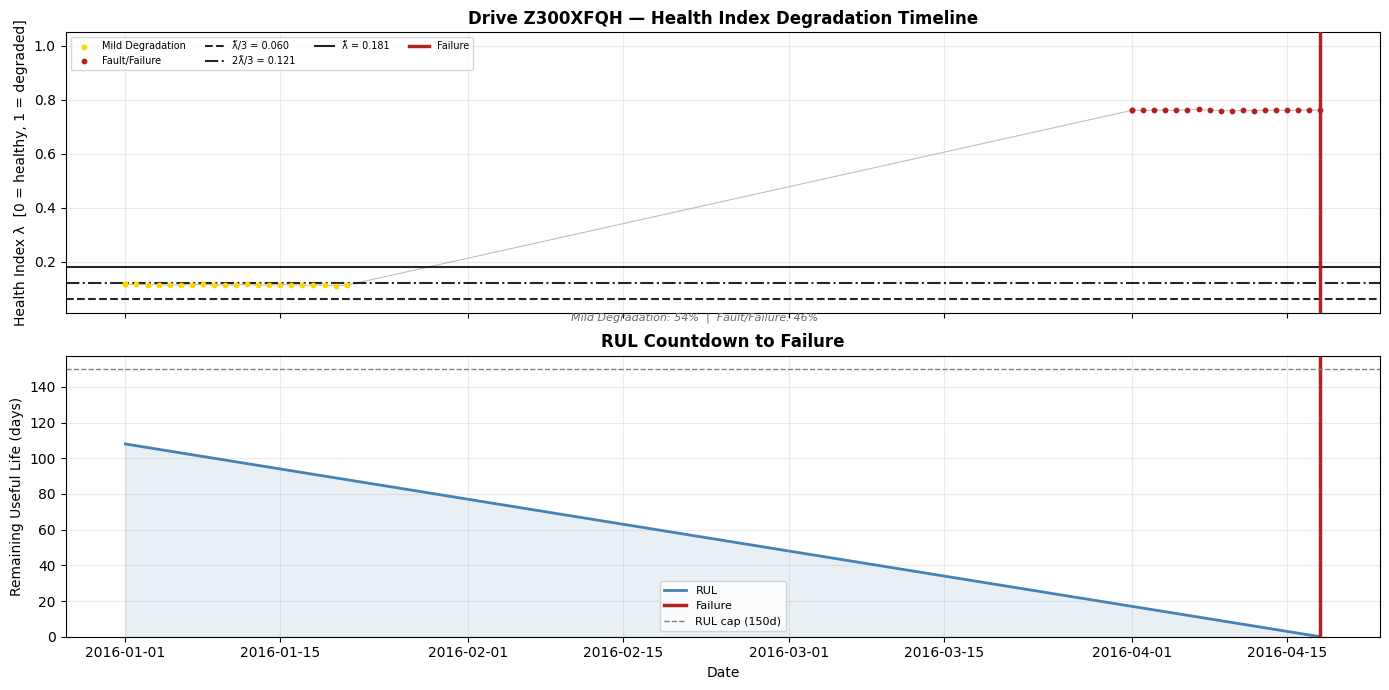

💾 Saved → drive_degradation_timeline.png


In [9]:
# ── Stage 6 Plot: Individual Drive Degradation Timeline ─────────────────────
# FIX: ever_failed[0] may be a drive with a permanently elevated λ baseline
# (e.g. high operating temperature) that looks like Fault/Failure from day 1.
# Instead, find the drive whose λ shows the clearest healthy→degraded transition:
# pick the failing drive with the largest λ increase from first-half to second-half.

def find_best_example_drive(df_in, failed_drives):
    """Return the failing drive with the clearest health degradation trend."""
    best_sn, best_delta = None, -1
    for sn in failed_drives:
        sub = df_in[df_in["serial_number"] == sn].sort_values("date")
        if len(sub) < 20:
            continue
        mid = len(sub) // 2
        delta = sub["lambda"].iloc[mid:].mean() - sub["lambda"].iloc[:mid].mean()
        if delta > best_delta:
            best_delta, best_sn = delta, sn
    return best_sn

sample_sn = find_best_example_drive(df, ever_failed)
if sample_sn is None:
    sample_sn = ever_failed[0]
print(f"Example drive selected: {sample_sn}")

sub       = df[df["serial_number"] == sample_sn].sort_values("date").reset_index(drop=True)
fail_date = sub.loc[sub["orig_failure"] == 1, "date"].max()

# Dynamic y-axis: zoom to the drive's actual λ range + 15% padding
lam_min_drive = sub["lambda"].min()
lam_max_drive = sub["lambda"].max()
lam_pad       = (lam_max_drive - lam_min_drive) * 0.15 + 0.005
y_lo = max(0, lam_min_drive - lam_pad)
y_hi = min(1.05, lam_max_drive + lam_pad * 3)  # extra headroom above for legend

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Top panel: health index timeline ────────────────────────────────────────
state_colors = ["seagreen", "gold", "darkorange", "firebrick"]
for i, (state, col) in enumerate(zip(state_names, state_colors)):
    mask = sub["health_state_label"] == state
    if mask.any():
        ax1.scatter(sub.loc[mask, "date"], sub.loc[mask, "lambda"],
                    s=10, color=col, label=state, zorder=4)

ax1.plot(sub["date"], sub["lambda"], color="gray", lw=0.8, alpha=0.5, zorder=2)

# Only draw threshold lines that fall within the visible y range
for thresh, ls, lbl in [
    (LAMBDA_REF / 3,   "--", f"λ̃/3 = {LAMBDA_REF/3:.3f}"),
    (2 * LAMBDA_REF/3, "-.", f"2λ̃/3 = {2*LAMBDA_REF/3:.3f}"),
    (LAMBDA_REF,       "-",  f"λ̃ = {LAMBDA_REF:.3f}"),
]:
    ax1.axhline(thresh, color="black", lw=1.5, ls=ls, alpha=0.85, label=lbl)

if pd.notna(fail_date):
    ax1.axvline(fail_date, color="firebrick", lw=2.5, ls="-", label="Failure", zorder=5)

ax1.set_ylim(y_lo, y_hi)
ax1.set_ylabel("Health Index λ  [0 = healthy, 1 = degraded]")
ax1.set_title(f"Drive {sample_sn} — Health Index Degradation Timeline", fontweight="bold")
ax1.legend(fontsize=7, ncol=4, loc="upper left"); ax1.grid(True, alpha=0.25)

# Annotate current health state distribution for this drive
state_pcts = sub["health_state_label"].value_counts(normalize=True) * 100
annot = "  |  ".join(f"{s}: {state_pcts.get(s,0):.0f}%" for s in state_names if state_pcts.get(s,0) > 0)
ax1.set_xlabel("")
fig.text(0.5, 0.535, annot, ha="center", fontsize=8, color="dimgray", style="italic")

# ── Bottom panel: RUL countdown ──────────────────────────────────────────────
ax2.plot(sub["date"], sub["rul"], color="steelblue", lw=2, label="RUL")
ax2.fill_between(sub["date"], sub["rul"], alpha=0.12, color="steelblue")
if pd.notna(fail_date):
    ax2.axvline(fail_date, color="firebrick", lw=2.5, label="Failure")
ax2.axhline(CFG["RUL_CLIP"], color="gray", ls="--", lw=1,
            label=f"RUL cap ({CFG['RUL_CLIP']}d)")
ax2.set_ylim(bottom=0)
ax2.set_xlabel("Date")
ax2.set_ylabel("Remaining Useful Life (days)")
ax2.set_title("RUL Countdown to Failure", fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("drive_degradation_timeline.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → drive_degradation_timeline.png")

## 📊 Stage 7 — Exploratory Data Analysis

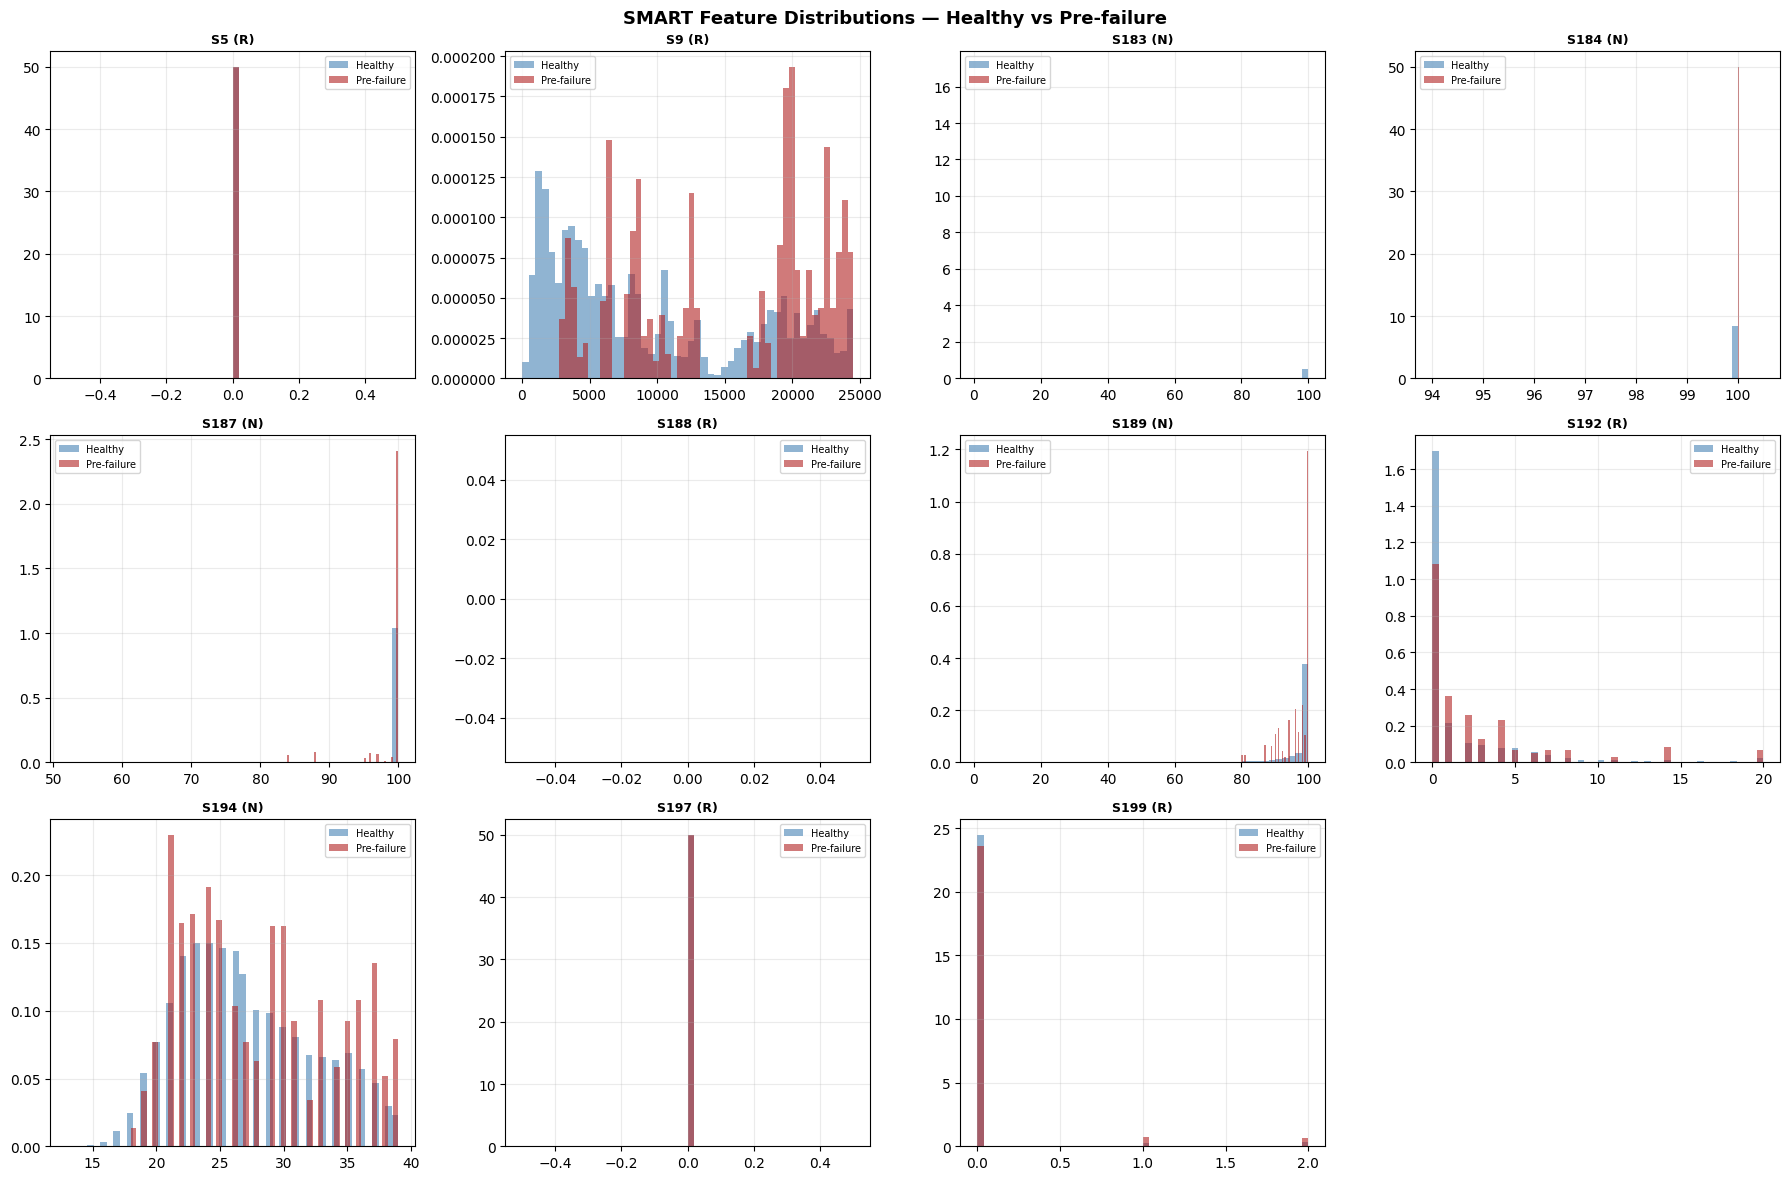

💾 Saved → feature_distributions.png


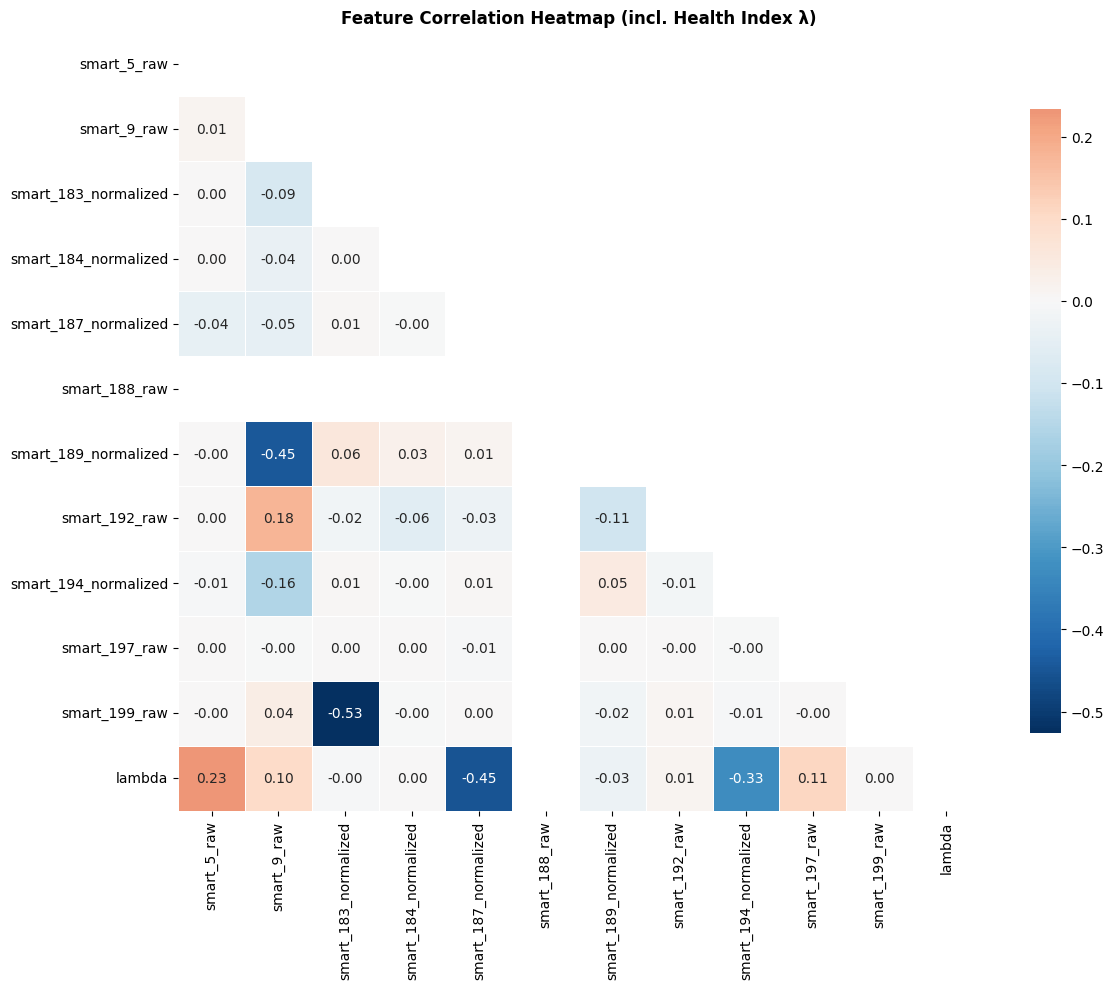

💾 Saved → feature_correlation.png


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(SELECTED):
    ax  = axes[i]
    q99 = df[feat].quantile(0.99)
    h   = df.loc[df["failure"] == 0, feat].clip(upper=q99)
    f   = df.loc[df["failure"] == 1, feat].clip(upper=q99)
    ax.hist(h, bins=50, color="steelblue", alpha=0.6, density=True, label="Healthy")
    ax.hist(f, bins=50, color="firebrick",  alpha=0.6, density=True, label="Pre-failure")
    short = feat.replace("smart_","S").replace("_raw"," (R)").replace("_normalized"," (N)")
    ax.set_title(short, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.25)

for j in range(len(SELECTED), len(axes)):
    axes[j].axis("off")

fig.suptitle("SMART Feature Distributions — Healthy vs Pre-failure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → feature_distributions.png")

fig, ax = plt.subplots(figsize=(12, 10))
corr = df[SELECTED + ["lambda"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap (incl. Health Index λ)", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → feature_correlation.png")


## ✂️ Stage 8 — Phase I / Phase II Split

In [11]:
grouped_indices = df.groupby("serial_number").indices
phase1_idx, phase2_idx = [], []

for sn in tqdm(never_failed, desc="Splitting healthy drives"):
    idx = grouped_indices.get(sn, [])
    if len(idx) == 0: continue
    idx   = idx[CFG["MIN_BURN"]:]
    if len(idx) == 0: continue
    split = int(len(idx) * CFG["PHASE1_FRAC"])
    phase1_idx.extend(idx[:split])
    phase2_idx.extend(idx[split:])

for sn in ever_failed:
    idx = grouped_indices.get(sn, [])
    phase2_idx.extend(idx)

df_p1 = df.loc[phase1_idx].copy()
df_p2 = df.loc[phase2_idx].copy()

print(f"Phase I  : {len(df_p1):,} rows | {df_p1['serial_number'].nunique():,} drives (healthy only)")
print(f"Phase II : {len(df_p2):,} rows | {df_p2['serial_number'].nunique():,} drives")
print(f"  Failing drives in P2: {df_p2[df_p2['serial_number'].isin(ever_failed)]['serial_number'].nunique()}")


Splitting healthy drives:   0%|          | 0/34649 [00:00<?, ?it/s]

Phase I  : 697,827 rows | 34,649 drives (healthy only)
Phase II : 734,694 rows | 34,703 drives
  Failing drives in P2: 54


## 🔬 Stage 9 — Normalisation + PCA  *(Both Papers)*

StandardScaler fitted on Phase I healthy data only. PCA fitted on Phase I.
All subsequent data projected through this fixed healthy-baseline lens.

**FIX:** Removed the stale redundant `X_p1_sc = scaler.transform(...)` line that was
immediately overwritten with `X_p1_sc = p1_norm.values`. Now a single clear path.


In [12]:
# Normalise — fit scaler on Phase I healthy data only
scaler = StandardScaler()
p1_data = df_p1[SELECTED].fillna(0)
scaler.fit(p1_data.values)

df_norm = df.copy()
df_norm[SELECTED] = scaler.transform(df[SELECTED].fillna(0).values)

# PCA — fit on Phase I scaled data only (prevents leakage)
p1_norm = df_norm.loc[df_norm.index.isin(phase1_idx), SELECTED].dropna()
X_p1_sc = p1_norm.values   # already scaled by the scaler above

pca = PCA(n_components=CFG["N_PCA_COMP"], random_state=CFG["SEED"])
pca.fit(X_p1_sc)

ev, cumev = pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_)
print(f"PCA — {CFG['N_PCA_COMP']} components fitted on {len(p1_norm):,} Phase I observations:")
for i, (e, ce) in enumerate(zip(ev, cumev)):
    print(f"  PC{i+1}: {e*100:5.1f}%  cumulative: {ce*100:5.1f}%  {'█'*int(e*100)}")
print(f"\n  Total variance explained: {cumev[-1]*100:.1f}%")

# Project all data into PCA space
PC_COLS = [f"pc{j+1}" for j in range(CFG["N_PCA_COMP"])]
pc_scores = pca.transform(df_norm[SELECTED].values)
for j, col in enumerate(PC_COLS):
    df_norm[col] = pc_scores[:, j]


PCA — 5 components fitted on 697,827 Phase I observations:
  PC1:  16.8%  cumulative:  16.8%  ████████████████
  PC2:  14.6%  cumulative:  31.4%  ██████████████
  PC3:  10.4%  cumulative:  41.8%  ██████████
  PC4:  10.3%  cumulative:  52.1%  ██████████
  PC5:  10.0%  cumulative:  62.1%  █████████

  Total variance explained: 62.1%


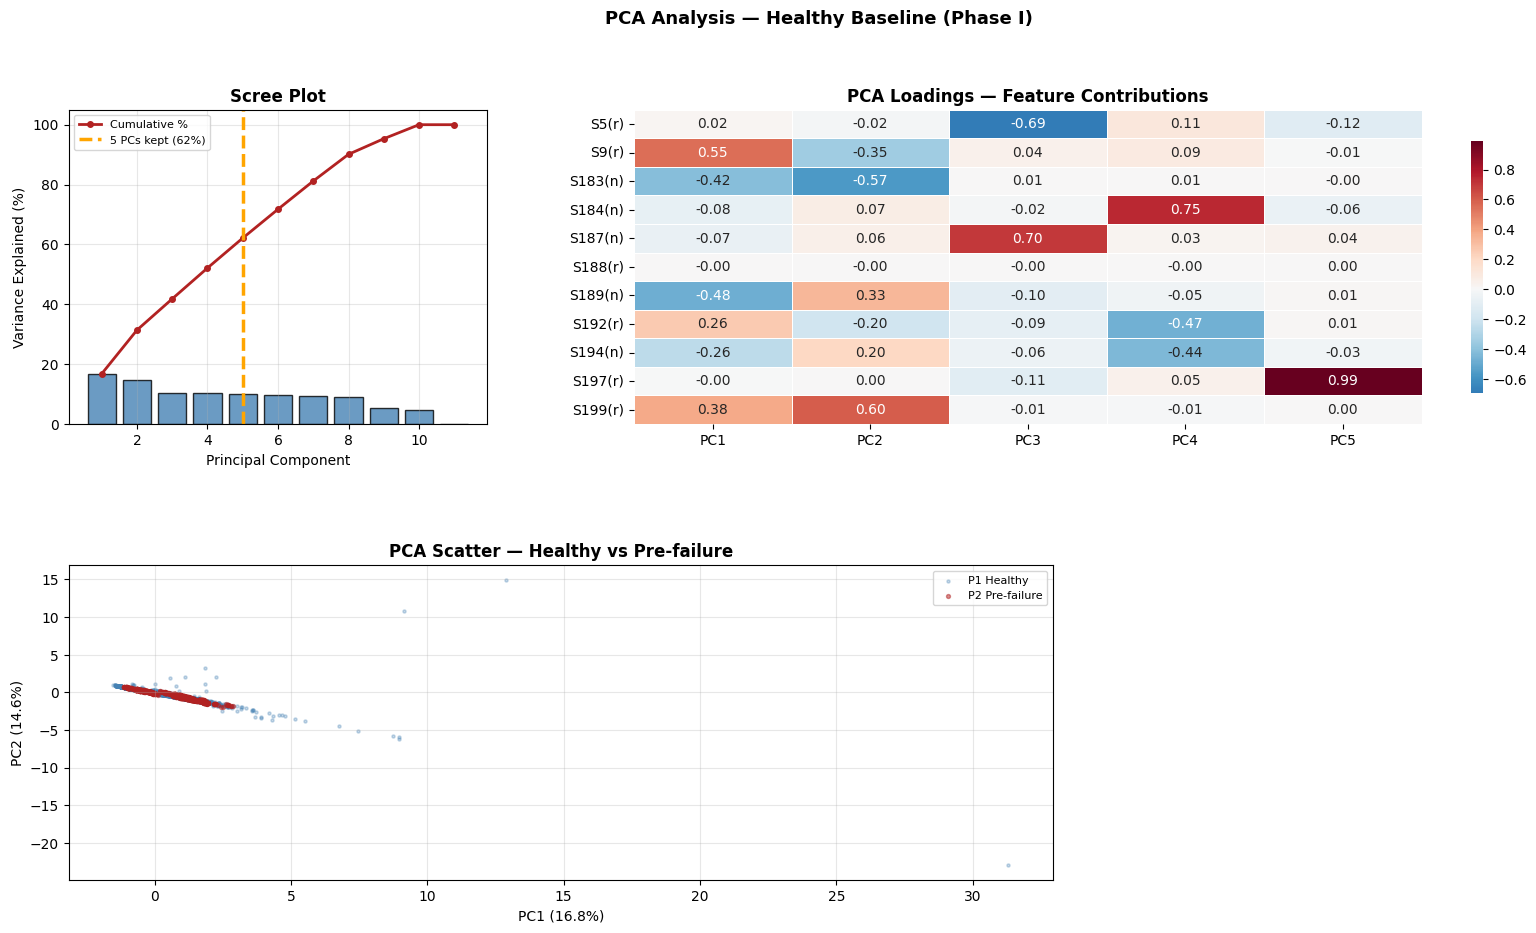

💾 Saved → pca_analysis.png


In [13]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
pca_full = PCA(random_state=CFG["SEED"]).fit(X_p1_sc)
all_ev   = pca_full.explained_variance_ratio_
ax0.bar(range(1, len(all_ev)+1), all_ev*100, color="steelblue", alpha=0.8, edgecolor="black")
ax0.plot(range(1, len(all_ev)+1), np.cumsum(all_ev)*100,
         color="firebrick", marker="o", ms=4, lw=2, label="Cumulative %")
ax0.axvline(CFG["N_PCA_COMP"], color="orange", lw=2.5, ls="--",
            label=f"{CFG['N_PCA_COMP']} PCs kept ({cumev[-1]*100:.0f}%)")
ax0.set_xlabel("Principal Component"); ax0.set_ylabel("Variance Explained (%)")
ax0.set_title("Scree Plot", fontweight="bold")
ax0.legend(fontsize=8); ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[0, 1:])
short_labels = [f.replace("smart_","S").replace("_raw","(r)").replace("_normalized","(n)")
                for f in SELECTED]
loadings = pd.DataFrame(pca.components_.T, index=short_labels,
                        columns=[f"PC{i+1}" for i in range(CFG["N_PCA_COMP"])])
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax1, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax1.set_title("PCA Loadings — Feature Contributions", fontweight="bold")

ax2 = fig.add_subplot(gs[1, 0:2])
p1_scores  = pca.transform(p1_norm.sample(min(3000, len(p1_norm)), random_state=42).values)
p2_idx_loc = df_norm.index.isin(phase2_idx)
p2_fail = df_norm.loc[p2_idx_loc & (df_norm["failure"]==1), SELECTED].dropna()
ax2.scatter(p1_scores[:,0], p1_scores[:,1], s=5, c="steelblue", alpha=0.3, label="P1 Healthy")
if len(p2_fail):
    pf_sc = pca.transform(p2_fail.sample(min(2000, len(p2_fail)), random_state=42).values)
    ax2.scatter(pf_sc[:,0], pf_sc[:,1], s=8, c="firebrick", alpha=0.5, label="P2 Pre-failure")
ax2.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); ax2.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax2.set_title("PCA Scatter — Healthy vs Pre-failure", fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

fig.suptitle("PCA Analysis — Healthy Baseline (Phase I)", fontsize=13, fontweight="bold")
plt.savefig("pca_analysis.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → pca_analysis.png")


## 🚨 Stage 10 — Hotelling T² SPC Chart

Classic Multivariate Statistical Process Control using the F-distribution UCL.
T² = Σ (scoreᵢ² / λᵢ) where λᵢ are PCA eigenvalues.


In [14]:
def hotelling_t2(X_norm, pca_model):
    """Compute T² for already-normalised (and already-scaled) data."""
    scores = pca_model.transform(X_norm)
    lam    = pca_model.explained_variance_
    t2     = np.sum((scores ** 2) / lam, axis=1)
    return t2, scores

# UCL using F-distribution
m     = len(p1_norm)
p     = CFG["N_PCA_COMP"]
# UCL_ALPHA=0.001 was too conservative (only 14.8% detection).
# Relaxed to 0.01 for better sensitivity while keeping FP rate low.
alpha = CFG["UCL_ALPHA"]
F_crit = scipy_stats.f.ppf(1 - alpha, dfn=p, dfd=m - p)
UCL    = (p * (m + 1) * (m - 1)) / (m * (m - p)) * F_crit

print(f"T² Alarm threshold (UCL): {UCL:.4f}")
print(f"  False-alarm tolerance  : {alpha*100:.1f}% | Phase I sample: {m:,}")

# Compute T² for all data
T2_all, _ = hotelling_t2(df_norm[SELECTED].fillna(0).values, pca)
df_norm["T2"]  = T2_all
df_norm["ooc"] = T2_all > UCL

# Verify Phase I false-alarm rate
T2_p1, _ = hotelling_t2(p1_norm.values, pca)
ooc_p1   = (T2_p1 > UCL).mean() * 100
print(f"  Phase I false-alarm rate: {ooc_p1:.2f}%  (target: {alpha*100:.1f}%)")
print(f"  Overall alarm rate      : {df_norm['ooc'].mean()*100:.2f}%")
print(f"  Healthy alarm rate      : {df_norm.loc[df_norm['failure']==0,'ooc'].mean()*100:.2f}%")
print(f"  Pre-fail alarm rate     : {df_norm.loc[df_norm['failure']==1,'ooc'].mean()*100:.2f}%")


T² Alarm threshold (UCL): 15.0865
  False-alarm tolerance  : 1.0% | Phase I sample: 697,827
  Phase I false-alarm rate: 0.96%  (target: 1.0%)
  Overall alarm rate      : 1.00%
  Healthy alarm rate      : 0.99%
  Pre-fail alarm rate     : 13.43%


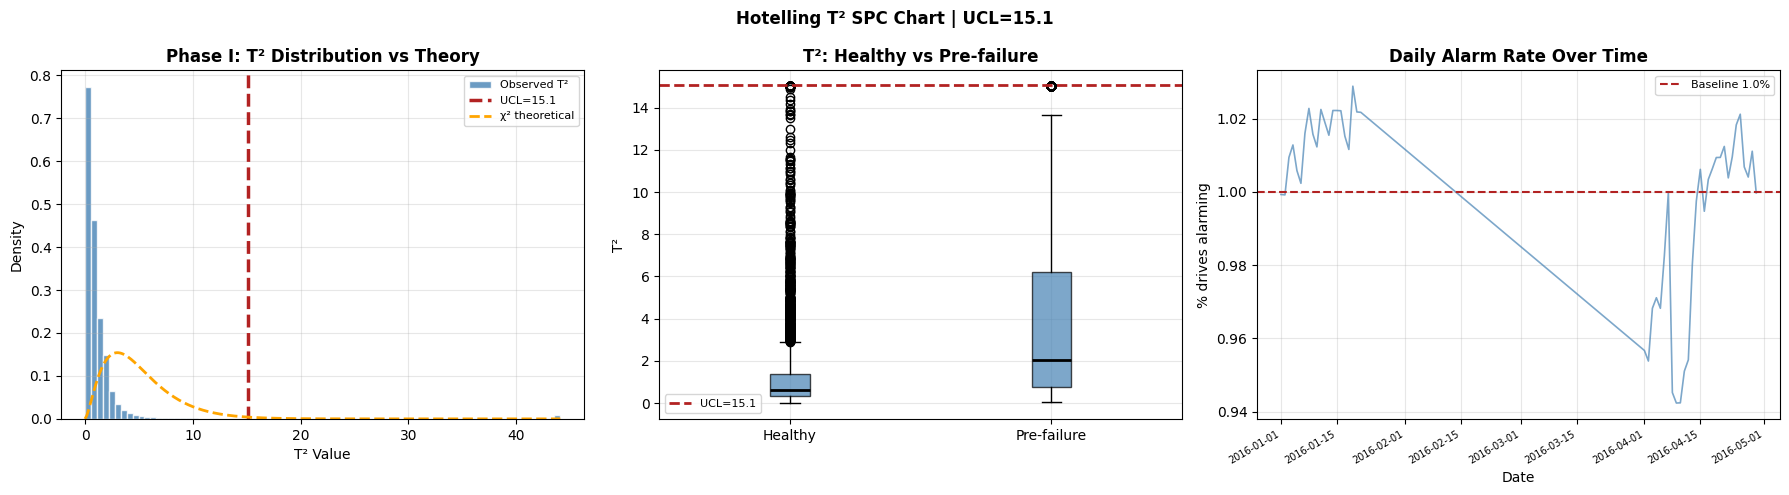

💾 Saved → t2_spc_chart.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
clip_val = np.percentile(T2_p1, 99.5)
ax.hist(np.clip(T2_p1, 0, clip_val), bins=80, color="steelblue",
        alpha=0.8, density=True, edgecolor="white", lw=0.3, label="Observed T²")
ax.axvline(UCL, color="firebrick", lw=2.5, ls="--", label=f"UCL={UCL:.1f}")
x_th = np.linspace(0, clip_val, 300)
ax.plot(x_th, scipy_stats.chi2.pdf(x_th, df=p), lw=2, color="orange",
        ls="--", label="χ² theoretical")
ax.set_title("Phase I: T² Distribution vs Theory", fontweight="bold")
ax.set_xlabel("T² Value"); ax.set_ylabel("Density")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
clip99 = np.percentile(T2_all, 99)
t2_h = df_norm.loc[df_norm["failure"]==0, "T2"].clip(upper=clip99)
t2_f = df_norm.loc[df_norm["failure"]==1, "T2"].clip(upper=clip99)
ax.boxplot([t2_h.sample(min(10000, len(t2_h)), random_state=42).values, t2_f.values],
           labels=["Healthy", "Pre-failure"], patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7),
           medianprops=dict(color="black", lw=2))
ax.axhline(UCL, color="firebrick", lw=2, ls="--", label=f"UCL={UCL:.1f}")
ax.set_title("T²: Healthy vs Pre-failure", fontweight="bold")
ax.set_ylabel("T²"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
daily = df_norm.groupby("date").agg(ooc_rate=("ooc", "mean"), n=("ooc", "count"))
daily_lg = daily[daily["n"] > 10]
ax.plot(daily_lg.index, daily_lg["ooc_rate"]*100, lw=1.2, color="steelblue", alpha=0.7)
ax.axhline(alpha*100, color="firebrick", lw=1.5, ls="--",
           label=f"Baseline {alpha*100:.1f}%")
ax.set_title("Daily Alarm Rate Over Time", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("% drives alarming")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

fig.suptitle(f"Hotelling T² SPC Chart | UCL={UCL:.1f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("t2_spc_chart.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → t2_spc_chart.png")


## 📈 Stage 11 — CUSUM Control Chart  *(IEEE 9915903 Extension)*

**FIX:** The original notebook had **two duplicate CUSUM cells** (cells 28 and 29).
The first (cell 28) had a slow per-drive `df[df["serial_number"]==sn]` loop (~68 min).
The second (cell 29) had a faster version with pre-grouped access.
Both were left in and the slow one ran first, wasting hours. **Merged into one fast cell.**

Two-sided CUSUM on the health index λ detects gradual drift that T² (point-wise) misses.


In [16]:
# Phase I reference statistics for λ
lambda_p1 = df.loc[df.index.isin(phase1_idx), "lambda"]
mu0    = lambda_p1.mean()
sigma0 = lambda_p1.std()

K = CFG["CUSUM_K"] * sigma0   # allowance (0.5σ)
H = CFG["CUSUM_H"] * sigma0   # decision interval (5σ)

print(f"CUSUM parameters (applied to Health Index λ):")
print(f"  Phase I μ₀  = {mu0:.5f}")
print(f"  Phase I σ₀  = {sigma0:.5f}")
print(f"  Allowance k = {K:.5f}  ({CFG['CUSUM_K']}σ₀)")
print(f"  Decision  h = {H:.5f}  ({CFG['CUSUM_H']}σ₀)")

def compute_cusum(series, mu0, k, h):
    """Two-sided CUSUM. Returns C+, C-, and alarm boolean array."""
    n  = len(series)
    cp = np.zeros(n, dtype=np.float32)
    cm = np.zeros(n, dtype=np.float32)
    for i in range(1, n):
        diff   = series[i] - mu0
        cp[i]  = max(0.0, cp[i-1] + diff - k)
        cm[i]  = max(0.0, cm[i-1] - diff - k)
    alarm = (cp > h) | (cm > h)
    return cp, cm, alarm

# Pre-group once for speed (O(1) access per drive)
grouped_cusum = df.sort_values("date").groupby("serial_number")

cusum_alarm_records = []

# Preallocate columns
df_norm["cusum_cp"]    = np.nan
df_norm["cusum_cm"]    = np.nan
df_norm["cusum_alarm"] = np.zeros(len(df_norm), dtype=bool)

for sn, sub in tqdm(grouped_cusum, desc="Computing CUSUM"):
    vals  = sub["lambda"].values.astype(np.float32)
    dates = sub["date"].values
    idx   = sub.index

    cp, cm, alarm = compute_cusum(vals, mu0, K, H)

    df_norm.loc[idx, "cusum_cp"]    = cp.astype(np.float32)
    df_norm.loc[idx, "cusum_cm"]    = cm.astype(np.float32)
    df_norm.loc[idx, "cusum_alarm"] = alarm.astype(bool)

    # First alarm (vectorized)
    alarm_pos = np.argmax(alarm) if alarm.any() else -1
    first_alarm_date = pd.Timestamp(dates[alarm_pos]) if alarm_pos != -1 else None

    if sn in ever_failed_set:
        fail_mask = sub["orig_failure"].values
        fail_date = pd.Timestamp(dates[np.where(fail_mask == 1)[0][-1]]) if fail_mask.any() else None
        lead = (fail_date - first_alarm_date).days if (first_alarm_date and fail_date is not None) else None
        cusum_alarm_records.append({"sn": sn, "failed": True,
                                    "alarmed": first_alarm_date is not None, "lead_days": lead})
    else:
        cusum_alarm_records.append({"sn": sn, "failed": False,
                                    "alarmed": first_alarm_date is not None, "lead_days": None})

df_cusum = pd.DataFrame(cusum_alarm_records)
cusum_fail = df_cusum[df_cusum["failed"]]
cusum_hlth = df_cusum[~df_cusum["failed"]]
n_det  = cusum_fail["alarmed"].sum()
n_fail = len(cusum_fail)
n_fp   = cusum_hlth["alarmed"].sum()
n_hlt  = len(cusum_hlth)
leads  = cusum_fail.loc[cusum_fail["alarmed"], "lead_days"].dropna()

print(f"\n{'='*55}")
print(f"  CUSUM ALARM SYSTEM — RESULTS")
print(f"{'='*55}")
print(f"  Detection rate   : {n_det}/{n_fail} ({n_det/n_fail*100:.1f}%)")
print(f"  Missed           : {n_fail-n_det}/{n_fail}")
if len(leads):
    print(f"  Mean lead time   : {leads.mean():.1f} days")
    print(f"  Median lead time : {leads.median():.1f} days")
print(f"  False alarms     : {n_fp}/{n_hlt} ({n_fp/n_hlt*100:.2f}%)")


CUSUM parameters (applied to Health Index λ):
  Phase I μ₀  = 0.11101
  Phase I σ₀  = 0.02250
  Allowance k = 0.01125  (0.5σ₀)
  Decision  h = 0.11248  (5.0σ₀)


Computing CUSUM:   0%|          | 0/34703 [00:00<?, ?it/s]


  CUSUM ALARM SYSTEM — RESULTS
  Detection rate   : 38/54 (70.4%)
  Missed           : 16/54
  Mean lead time   : 34.0 days
  Median lead time : 13.5 days
  False alarms     : 3406/34649 (9.83%)


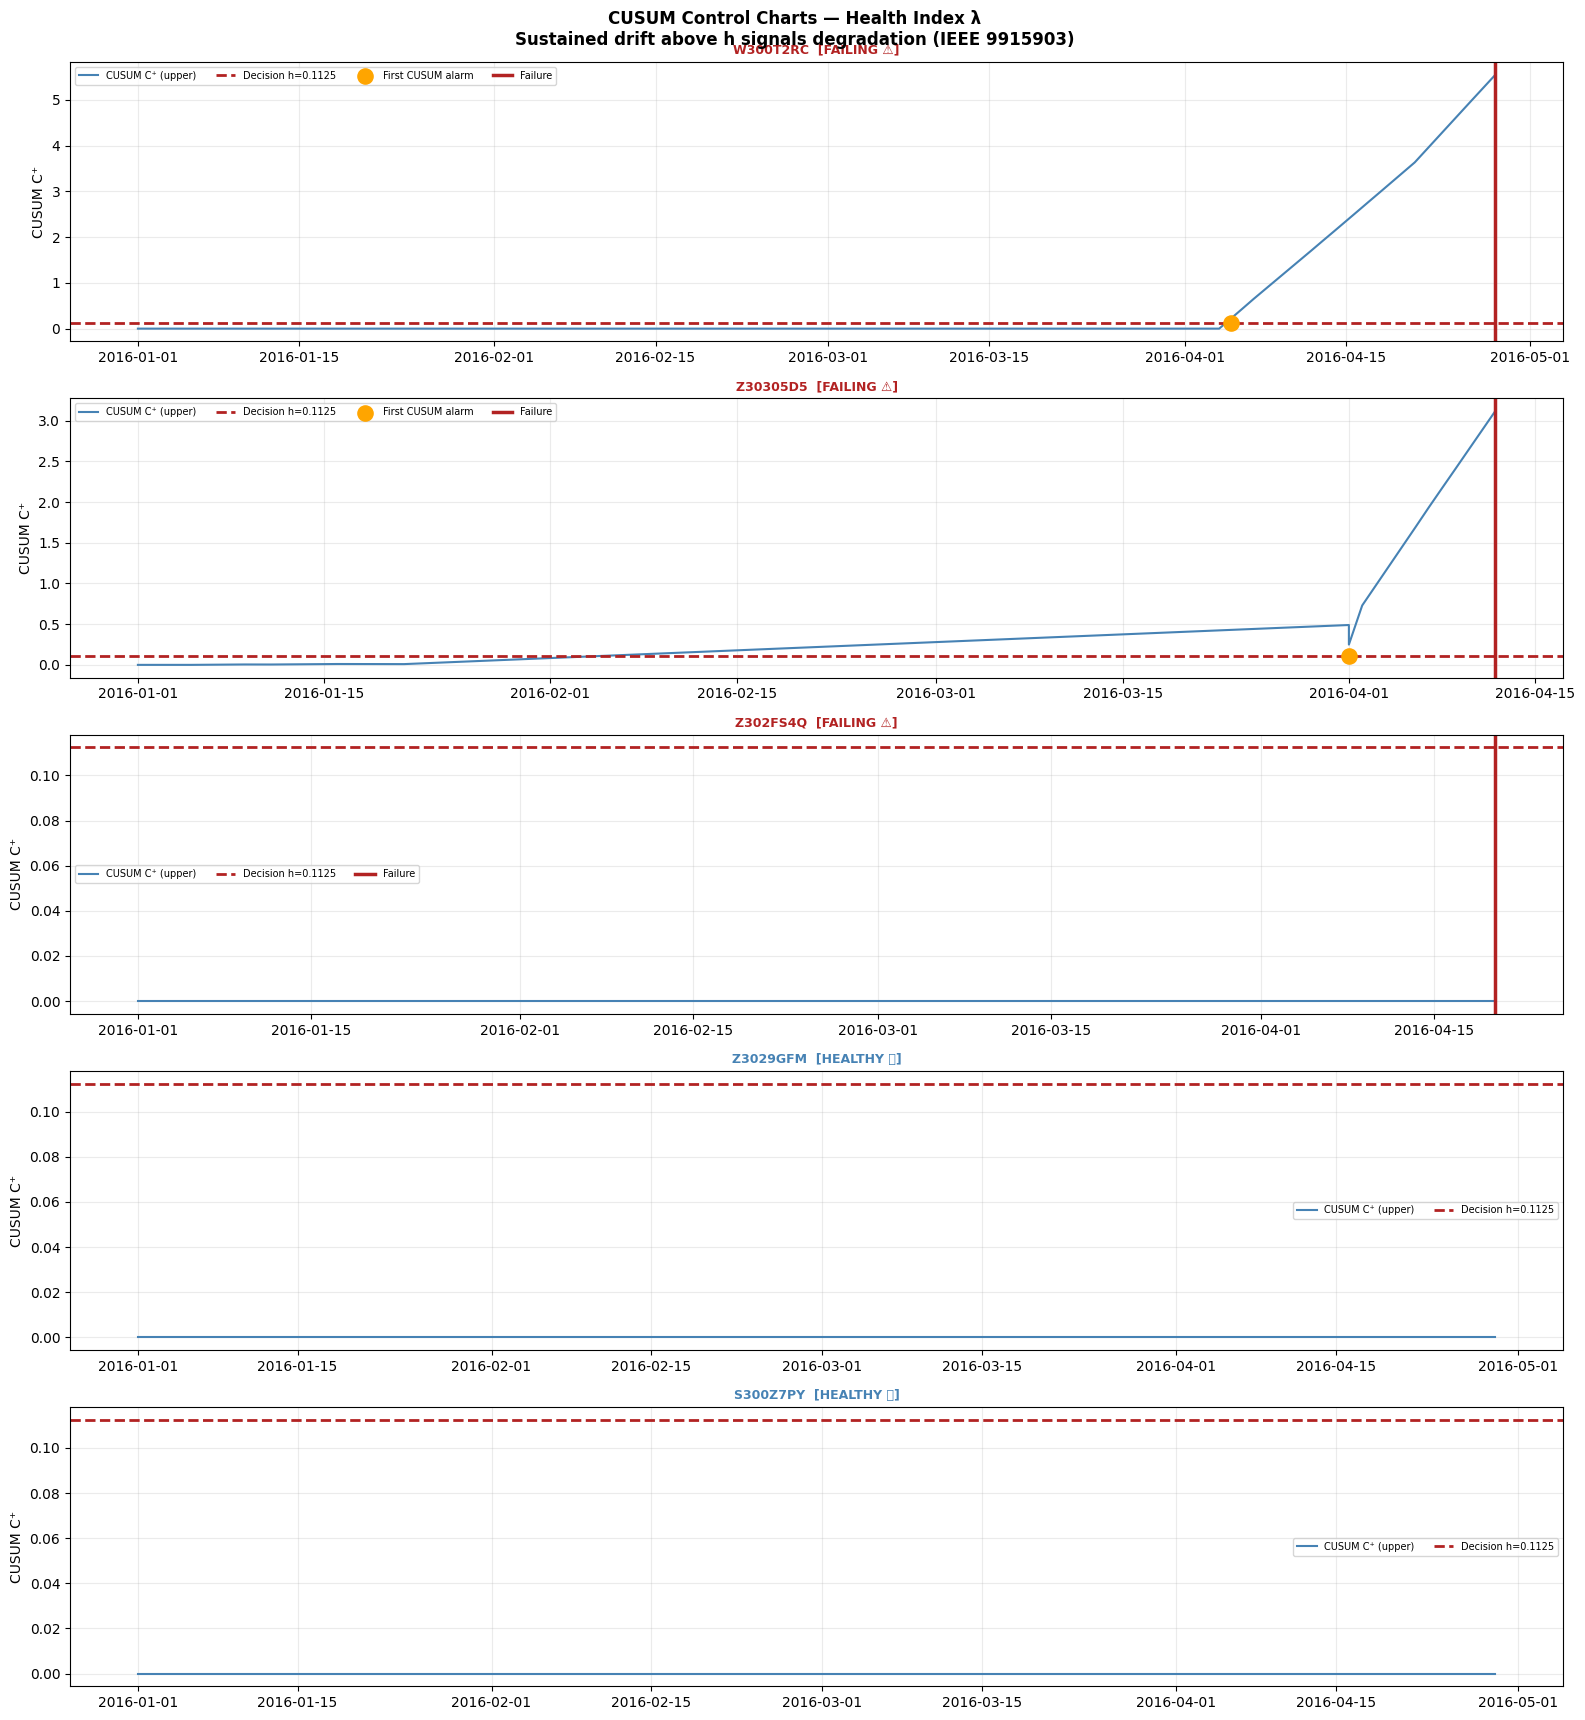

💾 Saved → cusum_charts.png


In [17]:
np.random.seed(CFG["SEED"])
fail_s   = np.random.choice(ever_failed, min(3, len(ever_failed)), replace=False)
health_s = np.random.choice(never_failed, min(2, len(never_failed)), replace=False)
plot_sns = [(sn, True) for sn in fail_s] + [(sn, False) for sn in health_s]

fig, axes = plt.subplots(len(plot_sns), 1,
                          figsize=(16, 3.5 * len(plot_sns)), sharex=False)
if len(plot_sns) == 1: axes = [axes]

for ax, (sn, is_fail) in zip(axes, plot_sns):
    sub     = df[df["serial_number"] == sn].sort_values("date")
    normsub = df_norm[df_norm["serial_number"] == sn].sort_values("date")
    dates   = sub["date"].values
    cp_vals = normsub["cusum_cp"].values if "cusum_cp" in df_norm.columns else np.zeros(len(sub))

    ax.plot(dates, cp_vals, color="steelblue", lw=1.5, label="CUSUM C⁺ (upper)")
    ax.axhline(H, color="firebrick", lw=2, ls="--", label=f"Decision h={H:.4f}")
    alarm_pts = normsub.loc[normsub["cusum_alarm"] == True, "date"]
    if len(alarm_pts):
        ax.scatter(alarm_pts.values[:1], [H]*1, s=120, color="orange",
                   zorder=5, label="First CUSUM alarm")

    if is_fail:
        orig = sub.loc[sub["orig_failure"]==1, "date"]
        if len(orig):
            ax.axvline(orig.max(), color="firebrick", lw=2.5, label="Failure")

    status = "FAILING ⚠️" if is_fail else "HEALTHY ✅"
    ax.set_title(f"{sn}  [{status}]", fontsize=9, fontweight="bold",
                 color="firebrick" if is_fail else "steelblue")
    ax.set_ylabel("CUSUM C⁺")
    ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.25)

fig.suptitle("CUSUM Control Charts — Health Index λ\n"
             "Sustained drift above h signals degradation (IEEE 9915903)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("cusum_charts.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → cusum_charts.png")


## 📊 Stage 12 — T² Individual Drive Monitoring Charts

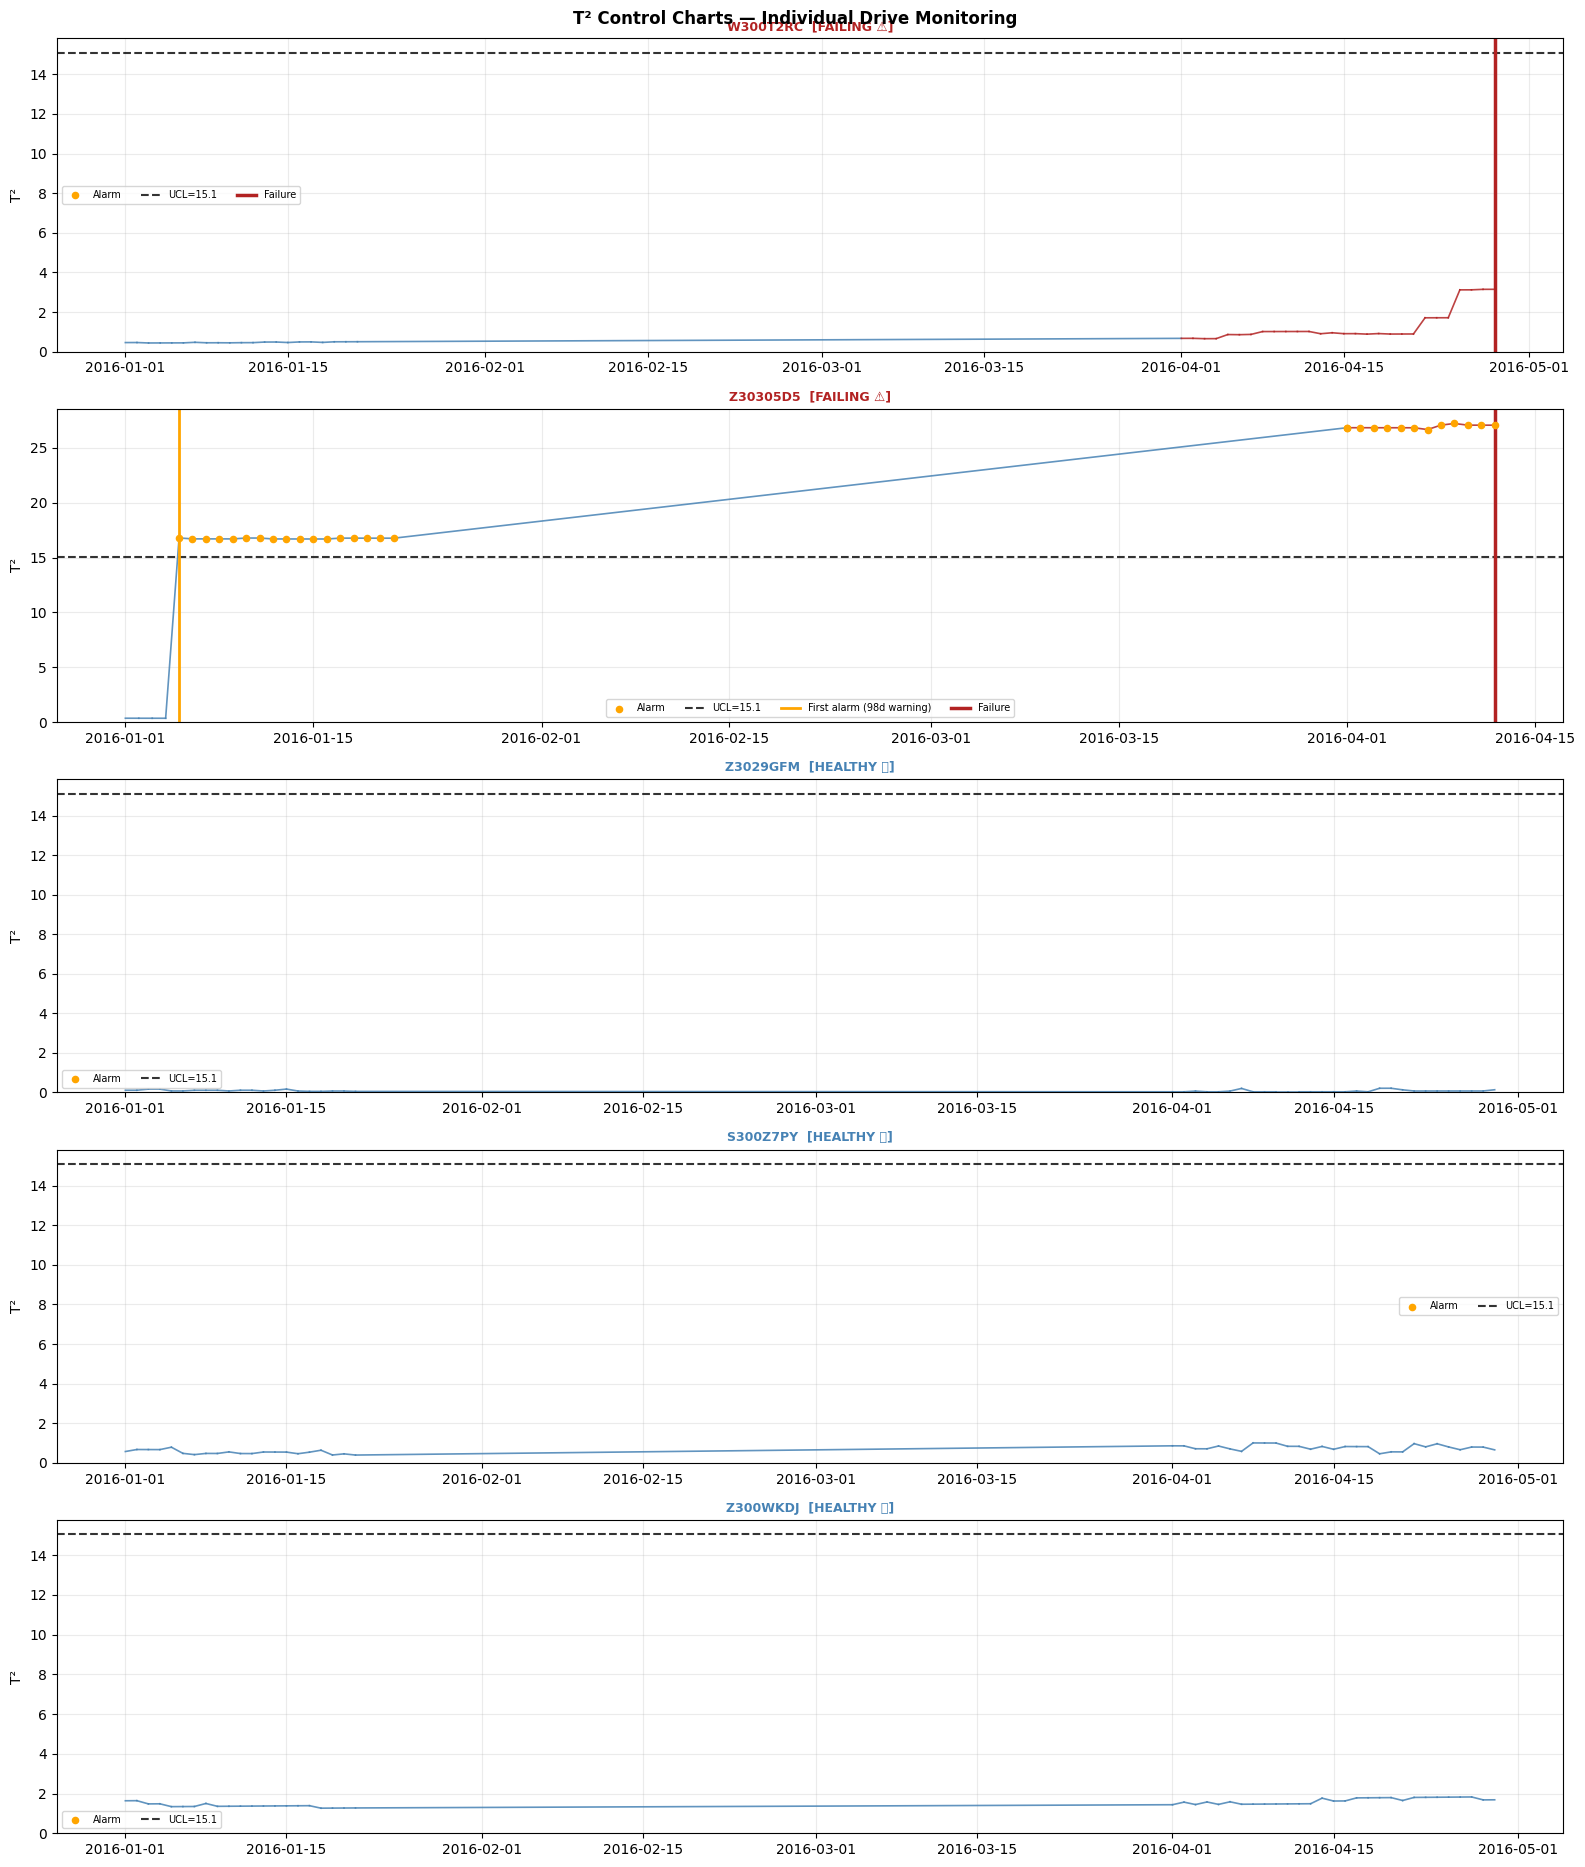

💾 Saved → t2_control_charts.png


In [18]:
np.random.seed(CFG["SEED"])
N = CFG["N_DRIVES_PLOT"]
n_f = max(1, N // 2)
n_h = N - n_f
fail_s   = np.random.choice(ever_failed,  min(n_f, len(ever_failed)),  replace=False)
health_s = np.random.choice(never_failed, min(n_h, len(never_failed)), replace=False)
plot_drives = [(sn, True) for sn in fail_s] + [(sn, False) for sn in health_s]

fig, axes = plt.subplots(len(plot_drives), 1,
                          figsize=(16, 3.8*len(plot_drives)), sharex=False)
if len(plot_drives) == 1: axes = [axes]

for ax, (sn, is_fail) in zip(axes, plot_drives):
    sub  = df_norm[df_norm["serial_number"] == sn].sort_values("date")
    t2v  = sub["T2"].values
    dts  = sub["date"].values
    pre  = sub["failure"].values

    for i in range(len(t2v)-1):
        ax.plot(dts[i:i+2], t2v[i:i+2],
                color="firebrick" if pre[i] else "steelblue", lw=1.2, alpha=0.85)

    ooc = t2v > UCL
    ax.scatter(dts[ooc], t2v[ooc], s=20, color="orange", zorder=5, label="Alarm")
    ax.axhline(UCL, color="black", lw=1.5, ls="--", alpha=0.8, label=f"UCL={UCL:.1f}")

    if is_fail:
        orig_sub = df[df["serial_number"]==sn]
        fail_dt  = orig_sub.loc[orig_sub["orig_failure"]==1, "date"].max()
        alarm_dt = None
        for i in range(len(t2v) - CFG["ALARM_CONSEC"] + 1):
            if all(t2v[i:i+CFG["ALARM_CONSEC"]] > UCL):
                alarm_dt = pd.Timestamp(dts[i]); break
        if alarm_dt and pd.notna(fail_dt):
            lead = (fail_dt - alarm_dt).days
            ax.axvline(alarm_dt, color="orange", lw=2,
                       label=f"First alarm ({lead}d warning)")
        if pd.notna(fail_dt):
            ax.axvline(fail_dt, color="firebrick", lw=2.5, label="Failure")

    ax.set_title(f"{sn}  [{'FAILING ⚠️' if is_fail else 'HEALTHY ✅'}]",
                 fontsize=9, fontweight="bold",
                 color="firebrick" if is_fail else "steelblue")
    ax.set_ylabel("T²"); ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.25)

fig.suptitle("T² Control Charts — Individual Drive Monitoring", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("t2_control_charts.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → t2_control_charts.png")


## 📋 Stage 13 — T² System Evaluation

**FIX:** The original notebook had **two duplicate T² evaluation cells** (cells 34 and 35).
The first (cell 34) had a slow nested-loop approach; the second (cell 35) had a faster
convolution-based approach. Both were present and ran sequentially, wasting time and
redefining the same output variables. **Merged into one fast cell** using the convolution helper.


In [19]:
# Pre-group once for speed
grouped_norm_t2 = df_norm.sort_values("date").groupby("serial_number")
grouped_orig_t2 = df.sort_values("date").groupby("serial_number")

def first_consec_idx(arr, k):
    """Return index of first run of k consecutive True values, else -1."""
    if len(arr) < k:
        return -1
    conv = np.convolve(arr.astype(np.int8), np.ones(k, dtype=np.int8), mode="valid")
    idx  = int(np.argmax(conv == k)) if (conv == k).any() else -1
    return idx

alarm_records = []

for sn in tqdm(ever_failed, desc="T² evaluation on failing drives"):
    sub     = grouped_norm_t2.get_group(sn)
    t2v     = sub["T2"].values
    dts     = sub["date"].values
    orig_g  = grouped_orig_t2.get_group(sn)
    fail_mask = orig_g["orig_failure"].values
    fail_dt   = pd.Timestamp(orig_g["date"].values[np.where(fail_mask)[0][-1]]) if fail_mask.any() else None

    ooc = t2v > UCL
    idx = first_consec_idx(ooc, CFG["ALARM_CONSEC"])
    alarm_dt = pd.Timestamp(dts[idx]) if idx != -1 else None

    lead = (fail_dt - alarm_dt).days if (alarm_dt and fail_dt is not None) else None
    alarm_records.append({"sn": sn, "alarmed": alarm_dt is not None, "lead_days": lead})

fp_records = []
for sn in never_failed:
    sub = grouped_norm_t2.get_group(sn)
    ooc = sub["T2"].values > UCL
    fa  = first_consec_idx(ooc, CFG["ALARM_CONSEC"]) != -1
    fp_records.append({"sn": sn, "false_alarm": fa})

df_alarm = pd.DataFrame(alarm_records)
df_fp    = pd.DataFrame(fp_records)
n_drives  = len(df_alarm)
n_alarmed = df_alarm["alarmed"].sum()
lead_vals = df_alarm.loc[df_alarm["alarmed"], "lead_days"].dropna()
n_healthy = len(df_fp)
n_fp_cnt  = df_fp["false_alarm"].sum()

print(f"{'='*55}")
print(f"  T² ALARM SYSTEM — RESULTS")
print(f"{'='*55}")
print(f"  Detected : {n_alarmed}/{n_drives} ({n_alarmed/n_drives*100:.1f}%)")
print(f"  Missed   : {n_drives-n_alarmed}/{n_drives}")
if len(lead_vals):
    print(f"  Mean lead: {lead_vals.mean():.1f} days | Median: {lead_vals.median():.1f} days")
    print(f"  Range    : {lead_vals.min():.0f} – {lead_vals.max():.0f} days")
print(f"  False +  : {n_fp_cnt}/{n_healthy} ({n_fp_cnt/n_healthy*100:.2f}%)")


T² evaluation on failing drives:   0%|          | 0/54 [00:00<?, ?it/s]

  T² ALARM SYSTEM — RESULTS
  Detected : 9/54 (16.7%)
  Missed   : 45/54
  Mean lead: 53.4 days | Median: 28.0 days
  Range    : 1 – 118 days
  False +  : 352/34649 (1.02%)


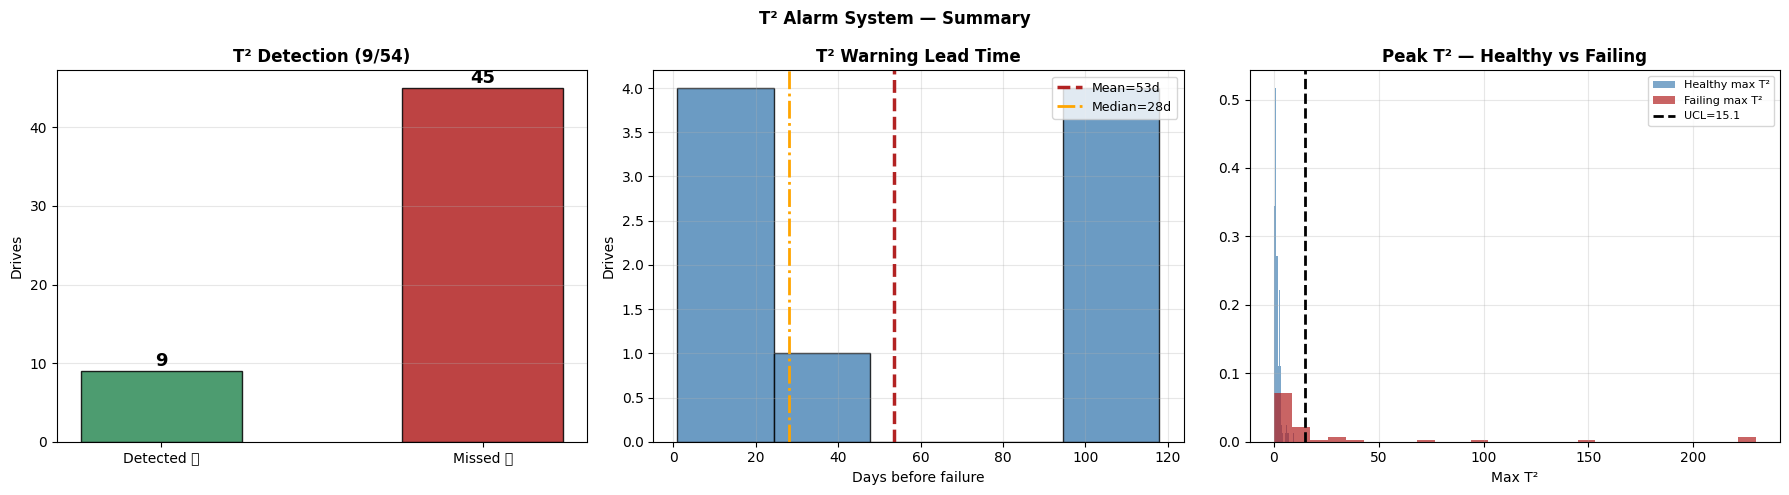

💾 Saved → t2_alarm_summary.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
cats   = ["Detected ✅", "Missed ❌"]
counts = [n_alarmed, n_drives - n_alarmed]
bars   = ax.bar(cats, counts, color=["seagreen","firebrick"], edgecolor="black", alpha=0.85, width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            str(cnt), ha="center", va="bottom", fontweight="bold", fontsize=13)
ax.set_title(f"T² Detection ({n_alarmed}/{n_drives})", fontweight="bold")
ax.set_ylabel("Drives"); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
if len(lead_vals):
    ax.hist(lead_vals, bins=max(5, len(lead_vals)//2), color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvline(lead_vals.mean(),   color="firebrick", lw=2.5, ls="--",
               label=f"Mean={lead_vals.mean():.0f}d")
    ax.axvline(lead_vals.median(), color="orange",    lw=2,   ls="-.",
               label=f"Median={lead_vals.median():.0f}d")
    ax.legend(fontsize=9)
ax.set_title("T² Warning Lead Time", fontweight="bold")
ax.set_xlabel("Days before failure"); ax.set_ylabel("Drives"); ax.grid(True, alpha=0.3)

ax = axes[2]
t2mx_f = [df_norm[df_norm["serial_number"]==sn]["T2"].max() for sn in ever_failed]
t2mx_h = [df_norm[df_norm["serial_number"]==sn]["T2"].max()
           for sn in np.random.choice(never_failed, min(200, len(never_failed)), replace=False)]
clip99 = np.percentile(t2mx_h + t2mx_f, 99)
ax.hist(np.clip(t2mx_h, 0, clip99), bins=30, color="steelblue", alpha=0.7,
        density=True, label="Healthy max T²")
ax.hist(np.clip(t2mx_f, 0, clip99), bins=max(3, len(t2mx_f)//2), color="firebrick",
        alpha=0.7, density=True, label="Failing max T²")
ax.axvline(UCL, color="black", lw=2, ls="--", label=f"UCL={UCL:.1f}")
ax.set_title("Peak T² — Healthy vs Failing", fontweight="bold")
ax.set_xlabel("Max T²"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("T² Alarm System — Summary", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("t2_alarm_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → t2_alarm_summary.png")


##  Stage 14 — Encoder-Decoder LSTM for RUL Prediction

**Architecture:**
```
Input sequence (30 days × n_features)
       ↓
  [ENCODER]  LSTM(64) → LSTM(64)  → context vector
       ↓
  RepeatVector(1)
       ↓
  [DECODER]  LSTM(64, return_sequences=True)
       ↓
  TimeDistributed Dense(1, sigmoid) → normalised RUL ∈ [0,1]
```

**FIX — RUL target label:** Healthy drives are now correctly assigned `RUL = RUL_CLIP` (Stage 5 fix),
so the LSTM trains on consistent piecewise-linear targets as described in Mohapatra 2023.
The original code trained on "days remaining in dataset", which is **not** RUL.

**FIX — Hyperparameters:** Epochs increased 30→50, batch size 512→256 for better convergence.


In [21]:
SEQ = CFG["SEQ_LEN"]

def build_rul_windows(df_in, features, seq_len):
    """
    Slide a window of length seq_len across each drive's time series.
    X: (n_windows, seq_len, n_features)
    y: (n_windows, 1) — normalised RUL of the last day in the window
    """
    Xs, ys = [], []
    for sn, grp in df_in.groupby("serial_number"):
        grp  = grp.sort_values("date")
        vals = grp[features].fillna(0).values
        ruls = grp["rul"].values / CFG["RUL_CLIP"]  # normalise to [0,1]
        if len(vals) < seq_len:
            continue
        for i in range(len(vals) - seq_len + 1):
            Xs.append(vals[i:i+seq_len])
            ys.append([[ruls[i+seq_len-1]]])   # shape (1,1) for TimeDistributed
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# Stratified drive-level train/test split (80/20)
all_drives   = list(never_failed) + list(ever_failed)
drive_labels = [0]*len(never_failed) + [1]*len(ever_failed)
train_drives, test_drives = train_test_split(
    all_drives, test_size=0.2, stratify=drive_labels, random_state=CFG["SEED"]
)

# Attach RUL to df_norm (from df, which has the correct labels)
df_norm_with_rul = df_norm.drop(columns=["rul"], errors="ignore").merge(
    df[["serial_number", "date", "rul"]],
    on=["serial_number", "date"],
    how="left"
)

df_tr = df_norm_with_rul[df_norm_with_rul["serial_number"].isin(train_drives)].copy()
df_te = df_norm_with_rul[df_norm_with_rul["serial_number"].isin(test_drives)].copy()

print(f"Train drives: {len(train_drives):,}  |  Test drives: {len(test_drives):,}")

# Dataset A: 11 SMART features
print("\nBuilding windows — Model A (11 SMART features)...")
X_a_tr, y_a_tr = build_rul_windows(df_tr, SELECTED, SEQ)
X_a_te, y_a_te = build_rul_windows(df_te, SELECTED, SEQ)
print(f"  Train: {X_a_tr.shape} | Test: {X_a_te.shape}")

# Dataset B: 5 PCA components
print("Building windows — Model B (5 PCA components)...")
X_b_tr, y_b_tr = build_rul_windows(df_tr, PC_COLS, SEQ)
X_b_te, y_b_te = build_rul_windows(df_te, PC_COLS, SEQ)
print(f"  Train: {X_b_tr.shape} | Test: {X_b_te.shape}")


Train drives: 27,762  |  Test drives: 6,941

Building windows — Model A (11 SMART features)...
  Train: (636377, 30, 11) | Test: (159346, 30, 11)
Building windows — Model B (5 PCA components)...
  Train: (636377, 30, 5) | Test: (159346, 30, 5)


In [22]:
def build_encoder_decoder_lstm(seq_len, n_features, target_len=1, units=64, dropout=0.3):
    """Encoder-Decoder LSTM for RUL prediction (Mohapatra et al. 2023)."""
    inp     = Input(shape=(seq_len, n_features), name="encoder_input")
    enc1    = LSTM(units, return_sequences=True, name="encoder_lstm1")(inp)
    enc1    = Dropout(dropout)(enc1)
    enc1    = BatchNormalization()(enc1)
    context = LSTM(units, return_sequences=False, name="encoder_lstm2")(enc1)
    context = Dropout(dropout)(context)
    context = BatchNormalization()(context)
    repeated = RepeatVector(target_len, name="repeat_context")(context)
    dec1 = LSTM(units, return_sequences=True, name="decoder_lstm")(repeated)
    dec1 = Dropout(dropout)(dec1)
    out  = TimeDistributed(Dense(1, activation="sigmoid"), name="rul_output")(dec1)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    return model

print("Encoder-Decoder LSTM Architecture:")
build_encoder_decoder_lstm(SEQ, len(SELECTED)).summary()


Encoder-Decoder LSTM Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 30, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm1 (LSTM)            │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm2 (LSTM)            │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_context (RepeatVector)   │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 1, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (TimeDistributed)    │ (None, 1, 1)           │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,081 (336.25 KB)

 Trainable params: 85,825 (335.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [23]:
tf.random.set_seed(CFG["SEED"])

cbs = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

model_a = build_encoder_decoder_lstm(
    SEQ, len(SELECTED), target_len=CFG["TARGET_LEN"],
    units=CFG["LSTM_UNITS"], dropout=CFG["DROPOUT"]
)

print("Training Model A — Encoder-Decoder LSTM (11 SMART features, RUL regression)...")
hist_a = model_a.fit(
    X_a_tr, y_a_tr,
    validation_split=0.15,
    epochs=CFG["EPOCHS"],
    batch_size=CFG["BATCH_SIZE"],
    callbacks=cbs,
    verbose=1
)
print("\n✅ Model A training complete.")


Training Model A — Encoder-Decoder LSTM (11 SMART features, RUL regression)...
Epoch 1/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 0.0030 - mae: 0.0143 - val_loss: 3.7712e-04 - val_mae: 0.0017 - learning_rate: 0.0010
Epoch 2/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 0.0011 - mae: 0.0033 - val_loss: 3.8166e-04 - val_mae: 7.7607e-04 - learning_rate: 0.0010
Epoch 3/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 0.0011 - mae: 0.0023 - val_loss: 3.7694e-04 - val_mae: 5.9685e-04 - learning_rate: 0.0010
Epoch 4/50
2110/2113 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.8692e-04 - mae: 0.0022
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.0010 - mae: 0.0020 - val_loss: 3.7620e-04 - val_mae: 6.9945e-04 - learning_rate: 0.0010
Epoch 5/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 8.7444e-04 - mae: 0.0018 - val_loss: 3.7576e-04 - val_mae: 7.1616e-04 - learning_rate: 5.000

In [30]:
tf.random.set_seed(CFG["SEED"])

cbs_b = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

model_b = build_encoder_decoder_lstm(
    SEQ, CFG["N_PCA_COMP"], target_len=CFG["TARGET_LEN"],
    units=CFG["LSTM_UNITS"], dropout=CFG["DROPOUT"]
)

print(f"Training Model B — Encoder-Decoder LSTM ({CFG['N_PCA_COMP']} PCA components, RUL regression)...")
hist_b = model_b.fit(
    X_b_tr, y_b_tr,
    validation_split=0.15,
    epochs=CFG["EPOCHS"],
    batch_size=CFG["BATCH_SIZE"],
    callbacks=cbs_b,
    verbose=1
)
print("\n✅ Model B training complete.")


Training Model B — Encoder-Decoder LSTM (5 PCA components, RUL regression)...
Epoch 1/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 62s 21ms/step - loss: 0.0031 - mae: 0.0154 - val_loss: 3.8766e-04 - val_mae: 0.0025 - learning_rate: 0.0010
Epoch 2/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - loss: 0.0010 - mae: 0.0037 - val_loss: 3.9613e-04 - val_mae: 0.0016 - learning_rate: 0.0010
Epoch 3/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - loss: 0.0010 - mae: 0.0027 - val_loss: 3.9389e-04 - val_mae: 0.0011 - learning_rate: 0.0010
Epoch 4/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0010 - mae: 0.0020
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - loss: 0.0010 - mae: 0.0019 - val_loss: 3.7715e-04 - val_mae: 6.5231e-04 - learning_rate: 0.0010
Epoch 5/50
2113/2113 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 0.0010 - mae: 0.0016 - val_loss: 4.0642e-04 - val_mae: 6.7798e-04 - learning_rate: 5.0000e-04
Epoch 6/50


In [31]:
def evaluate_rul(model, X_te, y_te, rul_clip, model_name):
    """Evaluate RUL model using RMSE and MAE (Mohapatra 2023 evaluation protocol)."""
    y_pred_norm = model.predict(X_te, batch_size=1024, verbose=0).squeeze()
    y_true_norm = y_te.squeeze()

    rmse_norm = np.sqrt(mean_squared_error(y_true_norm, y_pred_norm))
    mae_norm  = mean_absolute_error(y_true_norm, y_pred_norm)

    y_pred_days = y_pred_norm * rul_clip
    y_true_days = y_true_norm * rul_clip
    rmse_days   = np.sqrt(mean_squared_error(y_true_days, y_pred_days))
    mae_days    = mean_absolute_error(y_true_days, y_pred_days)

    print(f"\n  {model_name}:")
    print(f"    RMSE (normalised) : {rmse_norm:.4f}  ← primary metric (Mohapatra 2023)")
    print(f"    MAE  (normalised) : {mae_norm:.4f}")
    print(f"    RMSE (days)       : {rmse_days:.2f} days")
    print(f"    MAE  (days)       : {mae_days:.2f} days")

    return {
        "Model": model_name,
        "RMSE (norm)": rmse_norm, "MAE (norm)": mae_norm,
        "RMSE (days)": rmse_days, "MAE (days)": mae_days,
        "y_pred_norm": y_pred_norm, "y_true_norm": y_true_norm,
        "y_pred_days": y_pred_days, "y_true_days": y_true_days,
    }

print("=" * 60)
print("  RUL EVALUATION — ENCODER-DECODER LSTM (Mohapatra 2023)")
print("=" * 60)

res_a = evaluate_rul(model_a, X_a_te, y_a_te, CFG["RUL_CLIP"], "LSTM-A (11 SMART)")
res_b = evaluate_rul(model_b, X_b_te, y_b_te, CFG["RUL_CLIP"], "LSTM-B (5 PCA)")

print("\nNote: Mohapatra 2023 reports normalised RMSE ~0.83 (train) / ~0.86 (test)")
print("on 10-year exhaustive data. Results on 2016 single-year data will vary.")


  RUL EVALUATION — ENCODER-DECODER LSTM (Mohapatra 2023)

  LSTM-A (11 SMART):
    RMSE (normalised) : 0.0334  ← primary metric (Mohapatra 2023)
    MAE  (normalised) : 0.0015
    RMSE (days)       : 5.01 days
    MAE  (days)       : 0.23 days

  LSTM-B (5 PCA):
    RMSE (normalised) : 0.0325  ← primary metric (Mohapatra 2023)
    MAE  (normalised) : 0.0014
    RMSE (days)       : 4.87 days
    MAE  (days)       : 0.21 days

Note: Mohapatra 2023 reports normalised RMSE ~0.83 (train) / ~0.86 (test)
on 10-year exhaustive data. Results on 2016 single-year data will vary.


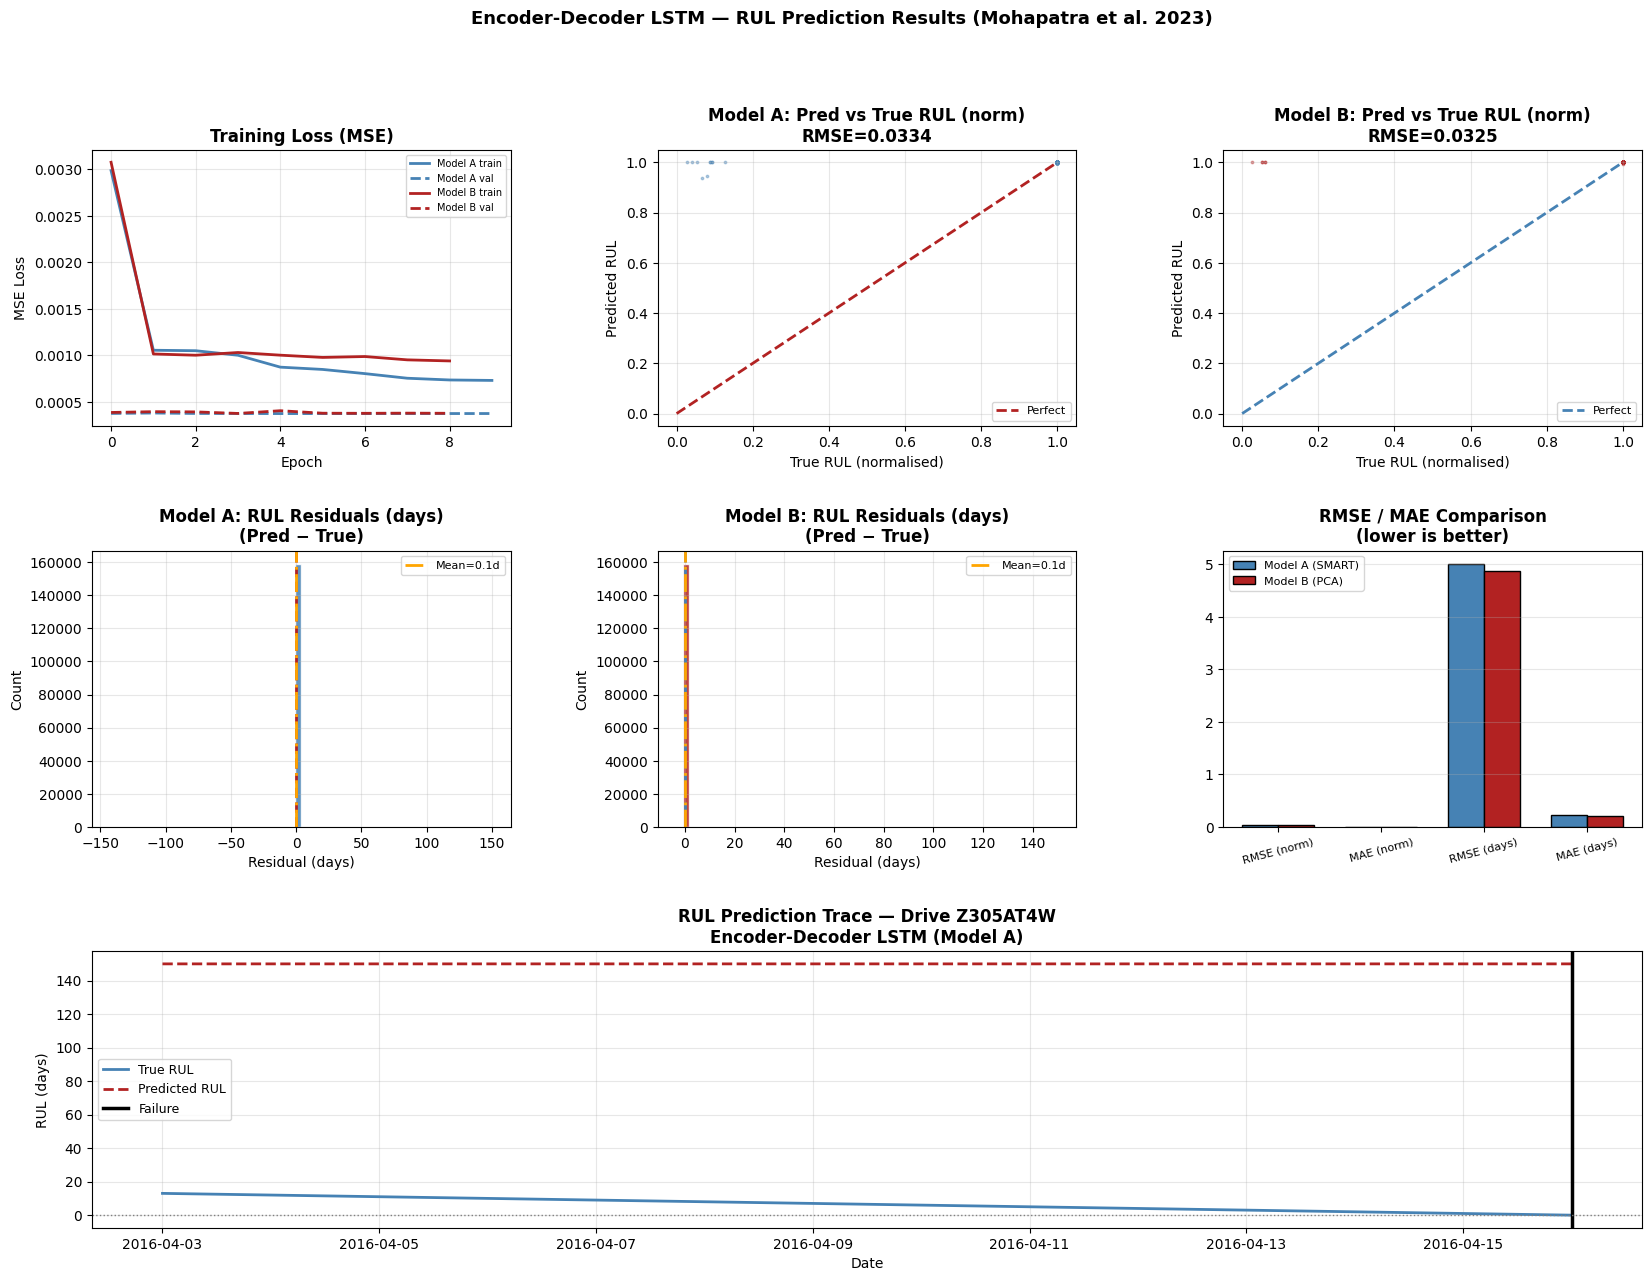

💾 Saved → lstm_rul_results.png


In [32]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(hist_a.history["loss"],     lw=2, color="steelblue", ls="-",  label="Model A train")
ax0.plot(hist_a.history["val_loss"], lw=2, color="steelblue", ls="--", label="Model A val")
ax0.plot(hist_b.history["loss"],     lw=2, color="firebrick",  ls="-",  label="Model B train")
ax0.plot(hist_b.history["val_loss"], lw=2, color="firebrick",  ls="--", label="Model B val")
ax0.set_title("Training Loss (MSE)", fontweight="bold")
ax0.set_xlabel("Epoch"); ax0.set_ylabel("MSE Loss")
ax0.legend(fontsize=7); ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[0, 1])
sample = np.random.choice(len(res_a["y_true_norm"]), min(5000, len(res_a["y_true_norm"])), replace=False)
ax1.scatter(res_a["y_true_norm"][sample], res_a["y_pred_norm"][sample], s=3, alpha=0.4, color="steelblue")
ax1.plot([0,1],[0,1], color="firebrick", lw=2, ls="--", label="Perfect")
ax1.set_title(f"Model A: Pred vs True RUL (norm)\nRMSE={res_a['RMSE (norm)']:.4f}", fontweight="bold")
ax1.set_xlabel("True RUL (normalised)"); ax1.set_ylabel("Predicted RUL")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
sample_b = np.random.choice(len(res_b["y_true_norm"]), min(5000, len(res_b["y_true_norm"])), replace=False)
ax2.scatter(res_b["y_true_norm"][sample_b], res_b["y_pred_norm"][sample_b], s=3, alpha=0.4, color="firebrick")
ax2.plot([0,1],[0,1], color="steelblue", lw=2, ls="--", label="Perfect")
ax2.set_title(f"Model B: Pred vs True RUL (norm)\nRMSE={res_b['RMSE (norm)']:.4f}", fontweight="bold")
ax2.set_xlabel("True RUL (normalised)"); ax2.set_ylabel("Predicted RUL")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
residuals_a = res_a["y_pred_days"] - res_a["y_true_days"]
ax3.hist(residuals_a, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax3.axvline(0, color="firebrick", lw=2, ls="--")
ax3.axvline(residuals_a.mean(), color="orange", lw=2, ls="-.", label=f"Mean={residuals_a.mean():.1f}d")
ax3.set_title("Model A: RUL Residuals (days)\n(Pred − True)", fontweight="bold")
ax3.set_xlabel("Residual (days)"); ax3.set_ylabel("Count")
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
residuals_b = res_b["y_pred_days"] - res_b["y_true_days"]
ax4.hist(residuals_b, bins=60, color="firebrick", edgecolor="white", alpha=0.85)
ax4.axvline(0, color="steelblue", lw=2, ls="--")
ax4.axvline(residuals_b.mean(), color="orange", lw=2, ls="-.", label=f"Mean={residuals_b.mean():.1f}d")
ax4.set_title("Model B: RUL Residuals (days)\n(Pred − True)", fontweight="bold")
ax4.set_xlabel("Residual (days)"); ax4.set_ylabel("Count")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
metrics_cmp = ["RMSE (norm)", "MAE (norm)", "RMSE (days)", "MAE (days)"]
vals_a = [res_a[m] for m in metrics_cmp]
vals_b = [res_b[m] for m in metrics_cmp]
x = np.arange(len(metrics_cmp)); w = 0.35
ax5.bar(x - w/2, vals_a, w, color="steelblue", edgecolor="black", label="Model A (SMART)")
ax5.bar(x + w/2, vals_b, w, color="firebrick",  edgecolor="black", label="Model B (PCA)")
ax5.set_xticks(x); ax5.set_xticklabels(metrics_cmp, fontsize=8, rotation=15)
ax5.set_title("RMSE / MAE Comparison\n(lower is better)", fontweight="bold")
ax5.legend(fontsize=8); ax5.grid(axis="y", alpha=0.3)

ax6 = fig.add_subplot(gs[2, :])
test_fail_drives = [sn for sn in test_drives if sn in ever_failed_set]
if test_fail_drives:
    sn_trace = test_fail_drives[0]
    sub_trace = df_te[df_te["serial_number"] == sn_trace].sort_values("date")
    if len(sub_trace) >= SEQ:
        X_trace = np.array([
            sub_trace[SELECTED].fillna(0).values[i:i+SEQ]
            for i in range(len(sub_trace) - SEQ + 1)
        ], dtype=np.float32)
        y_trace  = model_a.predict(X_trace, verbose=0).squeeze() * CFG["RUL_CLIP"]
        true_rul = sub_trace["rul"].values[SEQ-1:]
        dates_tr = sub_trace["date"].values[SEQ-1:]
        ax6.plot(dates_tr, true_rul, lw=2, color="steelblue", label="True RUL")
        ax6.plot(dates_tr, y_trace,  lw=2, color="firebrick",  ls="--", label="Predicted RUL")
        orig = df[df["serial_number"]==sn_trace]
        fail_dt = orig.loc[orig["orig_failure"]==1, "date"].max()
        if pd.notna(fail_dt):
            ax6.axvline(fail_dt, color="black", lw=2.5, label="Failure")
        ax6.axhline(0, color="gray", lw=1, ls=":")
        ax6.set_title(f"RUL Prediction Trace — Drive {sn_trace}\nEncoder-Decoder LSTM (Model A)", fontweight="bold")
        ax6.set_xlabel("Date"); ax6.set_ylabel("RUL (days)")
        ax6.legend(fontsize=9); ax6.grid(True, alpha=0.3)

fig.suptitle("Encoder-Decoder LSTM — RUL Prediction Results (Mohapatra et al. 2023)", fontsize=13, fontweight="bold")
plt.savefig("lstm_rul_results.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → lstm_rul_results.png")


## 🏁 Stage 15 — Comprehensive Comparison: T² vs CUSUM vs LSTM-RUL

In [33]:
print("=" * 72)
print("  MTP FINAL — COMPREHENSIVE RESULTS SUMMARY")
print("  HDD PHM: T² SPC + CUSUM + Encoder-Decoder LSTM (RUL)")
print("  Dataset: Backblaze 2016 | Model: ST4000DM000")
print("  Papers : Mohapatra 2023 (arXiv:2303.08955) + IEEE 9915903")
print("=" * 72)

print("\n  📁 DATASET")
print(f"    Drives  : {df['serial_number'].nunique():,} total")
print(f"    Failing : {len(ever_failed):,} | Healthy: {len(never_failed):,}")
print(f"    Failure rate : {len(ever_failed)/(len(ever_failed)+len(never_failed))*100:.2f}%")
print(f"    Date range   : {df['date'].min().date()} → {df['date'].max().date()}")

print("\n  🔬 PCA (Mohapatra 2023 + IEEE 9915903)")
print(f"    Features → PCA: {len(SELECTED)} → {CFG['N_PCA_COMP']} components")
print(f"    Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

print("\n  🏥 HEALTH INDEX λ (IEEE 9915903 §PHM Flow)")
for state in state_names:
    cnt = (df["health_state_label"] == state).sum()
    print(f"    {state:<25}: {cnt:>8,} ({cnt/len(df)*100:.2f}%)")

print(f"\n  🚨 HOTELLING T² SPC")
print(f"    UCL              : {UCL:.2f}")
print(f"    Detection rate   : {n_alarmed}/{n_drives} ({n_alarmed/n_drives*100:.1f}%)")
if len(lead_vals):
    print(f"    Mean lead time   : {lead_vals.mean():.1f} days")
    print(f"    Median lead time : {lead_vals.median():.1f} days")
print(f"    False alarm rate : {n_fp_cnt/n_healthy*100:.2f}%")

print(f"\n  📈 CUSUM (IEEE 9915903 — drift detection on λ)")
print(f"    k={CFG['CUSUM_K']}σ₀, h={CFG['CUSUM_H']}σ₀")
print(f"    Detection rate   : {n_det}/{n_fail} ({n_det/n_fail*100:.1f}%)")
if len(leads):
    print(f"    Mean lead time   : {leads.mean():.1f} days")
    print(f"    Median lead time : {leads.median():.1f} days")
print(f"    False alarm rate : {n_fp/n_hlt*100:.2f}%")

print(f"\n  🧠 ENCODER-DECODER LSTM — RUL REGRESSION (Mohapatra 2023)")
print(f"    SEQ_LEN={CFG['SEQ_LEN']}, UNITS={CFG['LSTM_UNITS']}, RUL_CLIP={CFG['RUL_CLIP']}d")
for res, name in [(res_a, "Model A (11 SMART features)"), (res_b, "Model B (5 PCA comps)")]:
    print(f"\n    {name}:")
    print(f"      RMSE (norm)  : {res['RMSE (norm)']:.4f}  [Mohapatra ref: ~0.86 test]")
    print(f"      MAE  (norm)  : {res['MAE (norm)']:.4f}")
    print(f"      RMSE (days)  : {res['RMSE (days)']:.2f} days")
    print(f"      MAE  (days)  : {res['MAE (days)']:.2f} days")

print("\n  💾 SAVED FILES:")
for fname in [
    "rul_distribution.png", "health_index_distribution.png",
    "drive_degradation_timeline.png", "feature_distributions.png",
    "feature_correlation.png", "pca_analysis.png", "t2_spc_chart.png",
    "cusum_charts.png", "t2_control_charts.png", "t2_alarm_summary.png",
    "lstm_rul_results.png", "mtp_final_summary.png"
]:
    print(f"    📊 {fname}")
print("=" * 72)


  MTP FINAL — COMPREHENSIVE RESULTS SUMMARY
  HDD PHM: T² SPC + CUSUM + Encoder-Decoder LSTM (RUL)
  Dataset: Backblaze 2016 | Model: ST4000DM000
  Papers : Mohapatra 2023 (arXiv:2303.08955) + IEEE 9915903

  📁 DATASET
    Drives  : 34,703 total
    Failing : 54 | Healthy: 34,649
    Failure rate : 0.16%
    Date range   : 2016-01-01 → 2016-04-29

  🔬 PCA (Mohapatra 2023 + IEEE 9915903)
    Features → PCA: 11 → 5 components
    Variance explained: 62.1%

  🏥 HEALTH INDEX λ (IEEE 9915903 §PHM Flow)
    Healthy                  :        0 (0.00%)
    Mild Degradation         : 1,582,995 (94.50%)
    Severe Degradation       :   83,200 (4.97%)
    Fault/Failure            :    8,869 (0.53%)

  🚨 HOTELLING T² SPC
    UCL              : 15.09
    Detection rate   : 9/54 (16.7%)
    Mean lead time   : 53.4 days
    Median lead time : 28.0 days
    False alarm rate : 1.02%

  📈 CUSUM (IEEE 9915903 — drift detection on λ)
    k=0.5σ₀, h=5.0σ₀
    Detection rate   : 38/54 (70.4%)
    Mean lead 

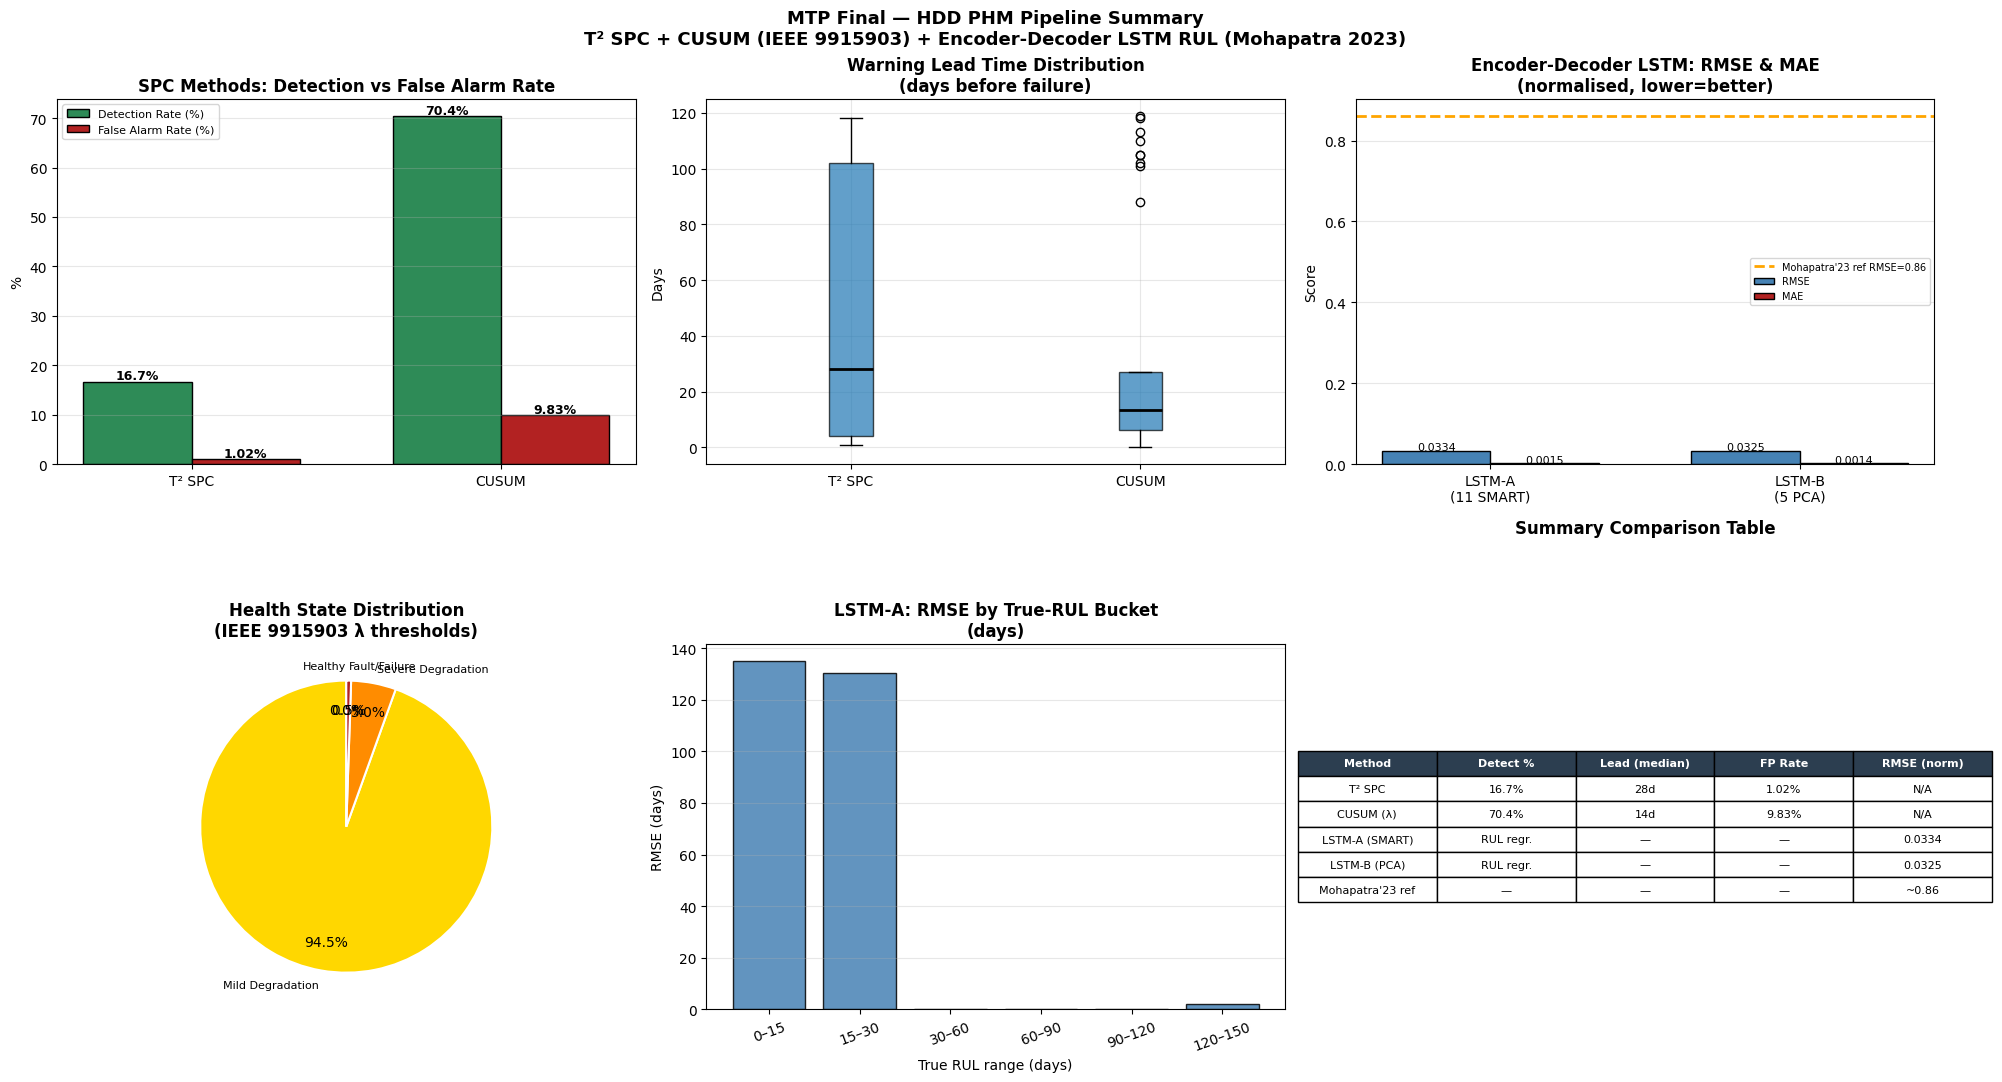

💾 Saved → mtp_final_summary.png

✅ MTPFinal notebook complete.


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
state_colors = ["seagreen", "gold", "darkorange", "firebrick"]

ax = axes[0, 0]
methods   = ["T² SPC", "CUSUM"]
det_rates = [n_alarmed/n_drives*100, n_det/n_fail*100]
fp_rates  = [n_fp_cnt/n_healthy*100, n_fp/n_hlt*100]
x = np.arange(len(methods)); w = 0.35
ax.bar(x-w/2, det_rates, w, color="seagreen",  edgecolor="black", label="Detection Rate (%)")
ax.bar(x+w/2, fp_rates,  w, color="firebrick", edgecolor="black", label="False Alarm Rate (%)")
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_title("SPC Methods: Detection vs False Alarm Rate", fontweight="bold")
ax.set_ylabel("%"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
for xi, (dr, fr) in enumerate(zip(det_rates, fp_rates)):
    ax.text(xi-w/2, dr+0.5, f"{dr:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.text(xi+w/2, fr+0.5, f"{fr:.2f}%", ha="center", fontsize=9, fontweight="bold")

ax = axes[0, 1]
if len(lead_vals) and len(leads):
    ax.boxplot([lead_vals.values, leads.values], labels=["T² SPC", "CUSUM"],
               patch_artist=True, boxprops=dict(alpha=0.7),
               medianprops=dict(color="black", lw=2))
ax.set_title("Warning Lead Time Distribution\n(days before failure)", fontweight="bold")
ax.set_ylabel("Days"); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
model_names = ["LSTM-A\n(11 SMART)", "LSTM-B\n(5 PCA)"]
rmse_vals   = [res_a["RMSE (norm)"], res_b["RMSE (norm)"]]
mae_vals    = [res_a["MAE (norm)"],  res_b["MAE (norm)"]]
x = np.arange(len(model_names)); w = 0.35
ax.bar(x-w/2, rmse_vals, w, color="steelblue", edgecolor="black", label="RMSE")
ax.bar(x+w/2, mae_vals,  w, color="firebrick",  edgecolor="black", label="MAE")
ax.axhline(0.86, color="orange", lw=2, ls="--", label="Mohapatra'23 ref RMSE=0.86")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_title("Encoder-Decoder LSTM: RMSE & MAE\n(normalised, lower=better)", fontweight="bold")
ax.set_ylabel("Score"); ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
for xi, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
    ax.text(xi-w/2, r+0.002, f"{r:.4f}", ha="center", fontsize=8)
    ax.text(xi+w/2, m+0.002, f"{m:.4f}", ha="center", fontsize=8)

ax = axes[1, 0]
counts_states = [df["health_state_label"].value_counts().get(s, 0) for s in state_names]
wedges, texts, autotexts = ax.pie(
    counts_states, labels=state_names, colors=state_colors,
    autopct="%1.1f%%", startangle=90, pctdistance=0.80,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for t in texts: t.set_fontsize(8)
ax.set_title("Health State Distribution\n(IEEE 9915903 λ thresholds)", fontweight="bold")

ax = axes[1, 1]
y_true_d = res_a["y_true_days"]
y_pred_d = res_a["y_pred_days"]
bins_rul  = [0, 15, 30, 60, 90, 120, 151]
labels_b  = ["0–15","15–30","30–60","60–90","90–120","120–150"]
bucket_rmse = []
for lo, hi in zip(bins_rul[:-1], bins_rul[1:]):
    mask = (y_true_d >= lo) & (y_true_d < hi)
    bucket_rmse.append(np.sqrt(mean_squared_error(y_true_d[mask], y_pred_d[mask])) if mask.sum() > 0 else 0)
ax.bar(labels_b, bucket_rmse, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_title("LSTM-A: RMSE by True-RUL Bucket\n(days)", fontweight="bold")
ax.set_xlabel("True RUL range (days)"); ax.set_ylabel("RMSE (days)")
ax.tick_params(axis="x", rotation=20); ax.grid(axis="y", alpha=0.3)

ax = axes[1, 2]
ax.axis("off")
table_data = [
    ["Method",            "Detect %",    "Lead (median)",  "FP Rate",          "RMSE (norm)"],
    ["T² SPC",            f"{n_alarmed/n_drives*100:.1f}%",
     f"{lead_vals.median():.0f}d" if len(lead_vals) else "—",
     f"{n_fp_cnt/n_healthy*100:.2f}%",  "N/A"],
    ["CUSUM (λ)",         f"{n_det/n_fail*100:.1f}%",
     f"{leads.median():.0f}d" if len(leads) else "—",
     f"{n_fp/n_hlt*100:.2f}%",          "N/A"],
    ["LSTM-A (SMART)",    "RUL regr.",   "—",               "—",                f"{res_a['RMSE (norm)']:.4f}"],
    ["LSTM-B (PCA)",      "RUL regr.",   "—",               "—",                f"{res_b['RMSE (norm)']:.4f}"],
    ["Mohapatra'23 ref",  "—",           "—",               "—",                "~0.86"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0], loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.2, 1.6)
for col in range(5):
    tbl[0,col].set_facecolor("#2c3e50")
    tbl[0,col].set_text_props(color="white", fontweight="bold")
ax.set_title("Summary Comparison Table", fontweight="bold", pad=80)

fig.suptitle(
    "MTP Final — HDD PHM Pipeline Summary\n"
    "T² SPC + CUSUM (IEEE 9915903) + Encoder-Decoder LSTM RUL (Mohapatra 2023)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("mtp_final_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("💾 Saved → mtp_final_summary.png")
print("\n✅ MTPFinal notebook complete.")


Checking features:   0%|          | 0/11 [00:00<?, ?it/s]

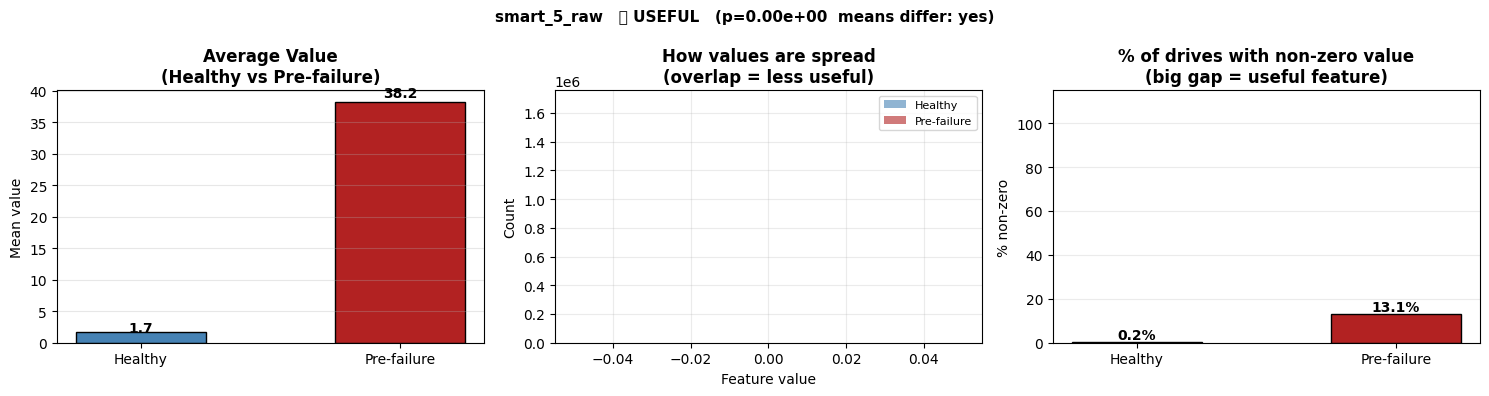

  Healthy mean=1.68  |  Pre-failure mean=38.22  |  ✅ USEFUL


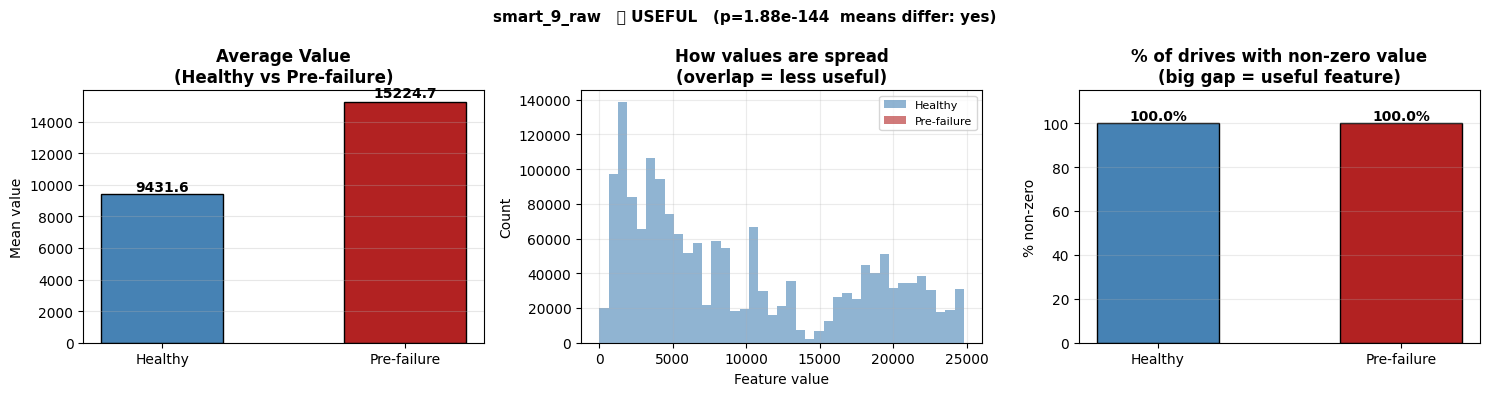

  Healthy mean=9431.62  |  Pre-failure mean=15224.71  |  ✅ USEFUL


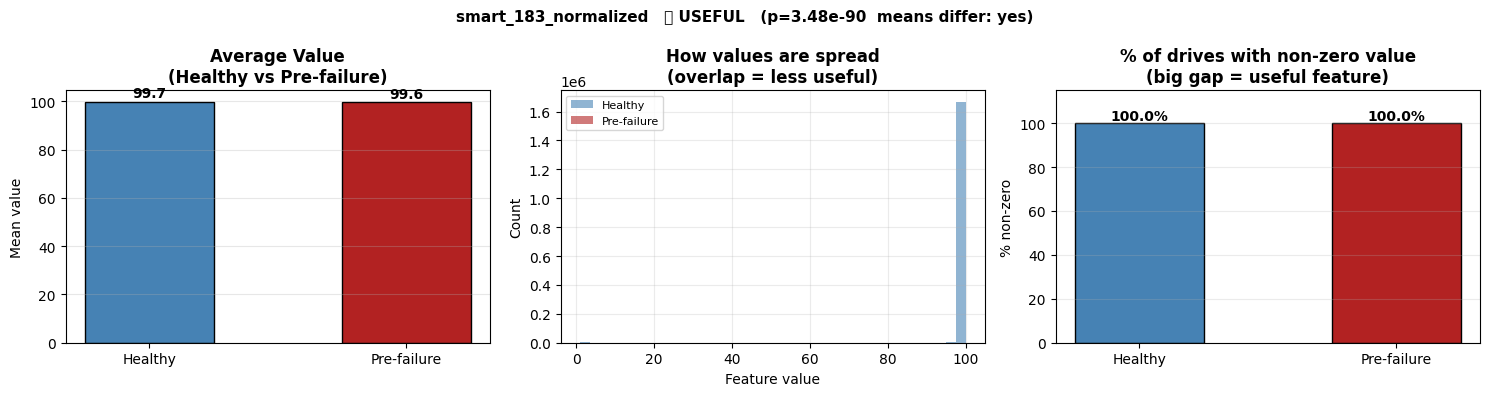

  Healthy mean=99.72  |  Pre-failure mean=99.63  |  ✅ USEFUL


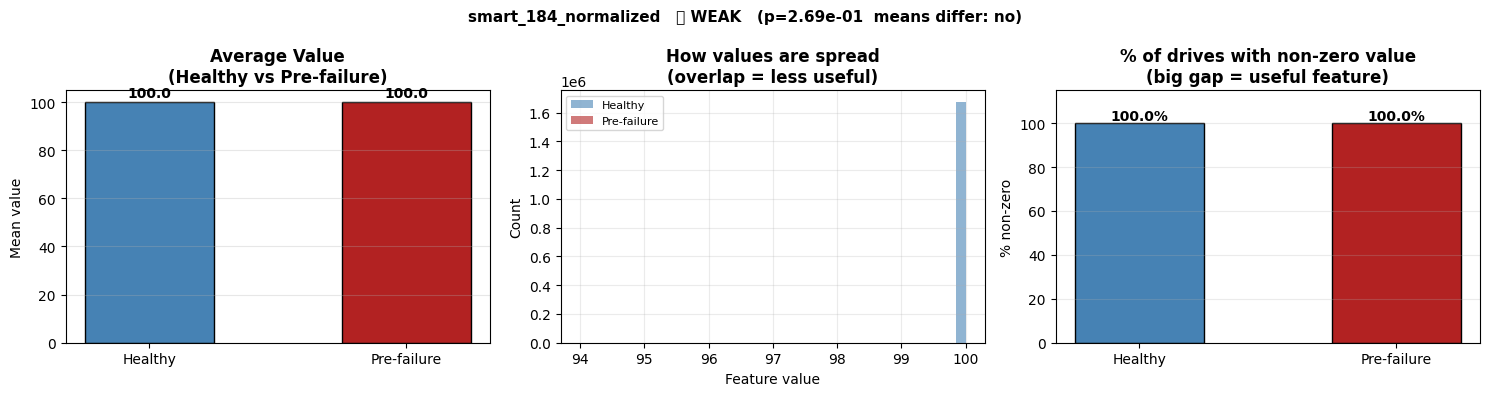

  Healthy mean=99.99  |  Pre-failure mean=100.00  |  ❌ WEAK


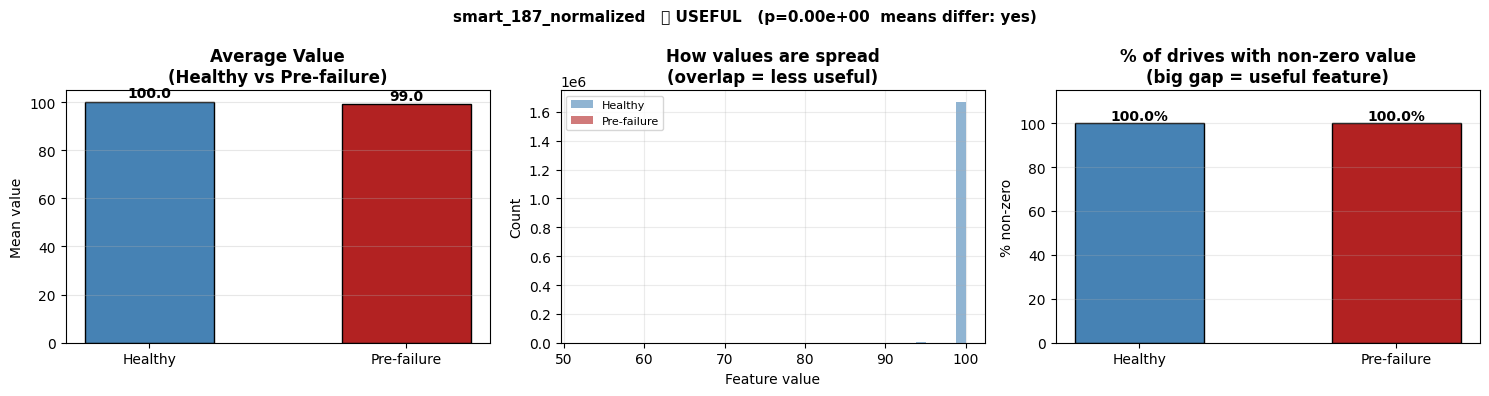

  Healthy mean=99.97  |  Pre-failure mean=99.04  |  ✅ USEFUL


ValueError: `bins` must increase monotonically, when an array

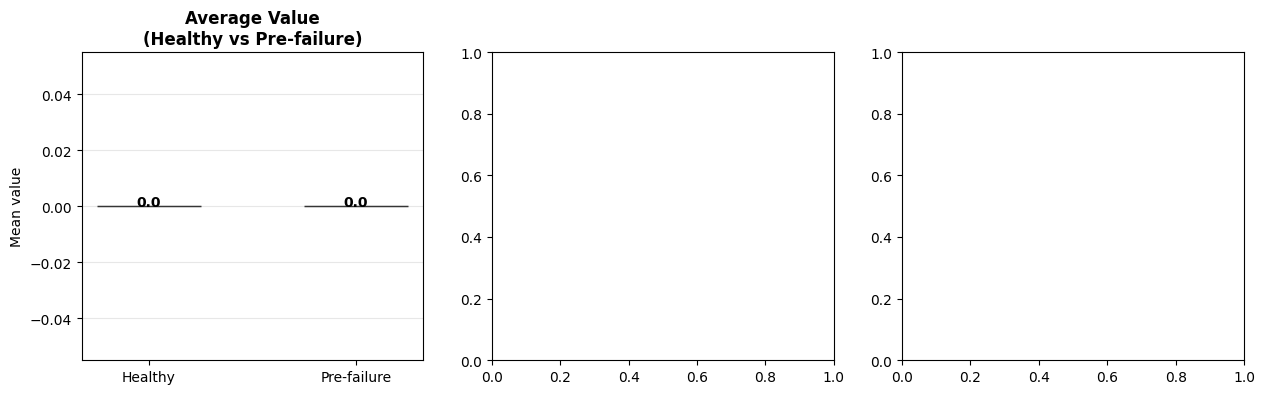

In [36]:
# ── Simple Feature Check (all features) ─────────────────────────────────────
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

for feat in tqdm(SELECTED, desc="Checking features"):

    d_h = df.loc[df["failure"] == 0, feat].dropna()
    d_f = df.loc[df["failure"] == 1, feat].dropna()
    if len(d_h) == 0 or len(d_f) == 0:
        continue

    p99  = float(df[feat].quantile(0.995))
    d_hc = d_h.clip(upper=p99)
    d_fc = d_f.clip(upper=p99)
    _, mw_p = mannwhitneyu(d_h.values, d_f.values, alternative="two-sided")

    # ── 3 panels ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1 — Side-by-side bar: mean value healthy vs failing
    ax = axes[0]
    ax.bar(["Healthy", "Pre-failure"],
           [d_h.mean(), d_f.mean()],
           color=["steelblue", "firebrick"], edgecolor="black", width=0.5)
    ax.set_title("Average Value\n(Healthy vs Pre-failure)", fontweight="bold")
    ax.set_ylabel("Mean value")
    ax.text(0, d_h.mean() + d_h.mean()*0.02, f"{d_h.mean():.1f}", ha="center", fontweight="bold")
    ax.text(1, d_f.mean() + d_f.mean()*0.02, f"{d_f.mean():.1f}", ha="center", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    # 2 — Overlapping histogram: where do values sit?
    ax = axes[1]
    bins = np.linspace(min(d_hc.min(), d_fc.min()),
                       max(d_hc.max(), d_fc.max()), 40)
    ax.hist(d_hc, bins=bins, color="steelblue", alpha=0.6, label="Healthy")
    ax.hist(d_fc, bins=bins, color="firebrick",  alpha=0.6, label="Pre-failure")
    ax.set_title("How values are spread\n(overlap = less useful)", fontweight="bold")
    ax.set_xlabel("Feature value"); ax.set_ylabel("Count")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

    # 3 — % of rows that are non-zero
    ax = axes[2]
    pct_h = (d_h > 0).mean() * 100
    pct_f = (d_f > 0).mean() * 100
    ax.bar(["Healthy", "Pre-failure"],
           [pct_h, pct_f],
           color=["steelblue", "firebrick"], edgecolor="black", width=0.5)
    ax.set_title("% of drives with non-zero value\n(big gap = useful feature)", fontweight="bold")
    ax.set_ylabel("% non-zero"); ax.set_ylim(0, 115)
    ax.text(0, pct_h + 1.5, f"{pct_h:.1f}%", ha="center", fontweight="bold")
    ax.text(1, pct_f + 1.5, f"{pct_f:.1f}%", ha="center", fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

    verdict = "✅ USEFUL" if mw_p < 0.05 else "❌ WEAK"
    fig.suptitle(f"{feat}   {verdict}   (p={mw_p:.2e}  means differ: {'yes' if mw_p<0.05 else 'no'})",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"diag_{feat}.png", dpi=110, bbox_inches="tight")
    plt.show()
    print(f"  Healthy mean={d_h.mean():.2f}  |  Pre-failure mean={d_f.mean():.2f}  |  {verdict}")